In [1]:
import os
import pandas as pd
import numpy as np

In [2]:
base_fold = '/home/h/Harini.Maruthi/Data'
fold_bam = base_fold + '/Bam_files/BigWig/src/clean'
os.chdir(fold_bam)
files_bam = [file for file in os.listdir() if '.csv' in file]

types = np.unique([file.split('_')[0] for file in files_bam])
samples = np.unique([file.split('_')[1]+'_'+file.split('_')[2] for file in files_bam])

file_dict = {}
for t in types:
    file_dict[t] = {}
    files_t = [file for file in files_bam if t in file]
    for sample in samples:
        file_dict[t][sample] = [file for file in files_t if sample in file]

In [3]:
file_dict

{'matrixDMC1-WT-164': {'R1_T1.sorted.unparsed': ['matrixDMC1-WT-164_R1_T1.sorted.unparsed_type1.forward.bw.csv',
   'matrixDMC1-WT-164_R1_T1.sorted.unparsed_type1.reverse.bw.csv'],
  'R2_T1.sorted.unparsed': ['matrixDMC1-WT-164_R2_T1.sorted.unparsed_type1.forward.bw.csv',
   'matrixDMC1-WT-164_R2_T1.sorted.unparsed_type1.reverse.bw.csv'],
  'R3_T1.sorted.unparsed': ['matrixDMC1-WT-164_R3_T1.sorted.unparsed_type1.reverse.bw.csv',
   'matrixDMC1-WT-164_R3_T1.sorted.unparsed_type1.forward.bw.csv']},
 'matrixDMC1-WT-176': {'R1_T1.sorted.unparsed': ['matrixDMC1-WT-176_R1_T1.sorted.unparsed_type1.reverse.bw.csv',
   'matrixDMC1-WT-176_R1_T1.sorted.unparsed_type1.forward.bw.csv'],
  'R2_T1.sorted.unparsed': ['matrixDMC1-WT-176_R2_T1.sorted.unparsed_type1.reverse.bw.csv',
   'matrixDMC1-WT-176_R2_T1.sorted.unparsed_type1.forward.bw.csv'],
  'R3_T1.sorted.unparsed': ['matrixDMC1-WT-176_R3_T1.sorted.unparsed_type1.forward.bw.csv',
   'matrixDMC1-WT-176_R3_T1.sorted.unparsed_type1.reverse.bw.csv'

In [4]:

def average_replicate_matrices(data_dict, matrix_dir, load_func=pd.read_csv):
    """
    Load and average coverage matrices (forward & reverse) for each experiment.
    
    Args:
        data_dict: nested dict {experiment: {replicate: [reverse_path, forward_path]}}
        matrix_dir: path to directory containing coverage matrix files
        load_func: function to load matrix file (default: pd.read_csv)
    
    Returns:
        dict_mat: {experiment: {'forward': DataFrame, 'reverse': DataFrame}}
    """
    dict_mat = {}

    for experiment, replicates in data_dict.items():
        forward_matrices = []
        reverse_matrices = []

        for rep_name, files in replicates.items():
            # Identify which file is forward/reverse
            forward_file = next(f for f in files if "forward" in f)
            reverse_file = next(f for f in files if "reverse" in f)

            # Load the matrices
            forward_path = os.path.join(matrix_dir, forward_file)
            reverse_path = os.path.join(matrix_dir, reverse_file)

            fwd_df = load_func(forward_path, index_col=0)
            rev_df = load_func(reverse_path, index_col=0)

            forward_matrices.append(fwd_df)
            reverse_matrices.append(rev_df)

        # Compute mean across replicates (aligned by index/columns)
        forward_avg = sum(forward_matrices) / len(forward_matrices)
        forward_avg.to_csv(f'avgforwardmatrix{experiment}.csv')
        reverse_avg = sum(reverse_matrices) / len(reverse_matrices)
        reverse_avg.to_csv(f'avgreversematrix{experiment}.csv')

        dict_mat[experiment] = {
            "forward": forward_avg,
            "reverse": reverse_avg
        }

    return dict_mat


In [5]:
matrix_dir = os.getcwd()
dict_mat = average_replicate_matrices(file_dict, matrix_dir)

In [6]:
dict_mat

{'matrixDMC1-WT-164': {'forward':                               -200      -199      -198  -197      -196  -195  \
  chr1:59358990-59359564    0.000000  0.000000  0.000000   0.0  0.000000   0.0   
  chr1:86088048-86088880    0.000000  0.000000  0.000000   0.0  0.000000   0.0   
  chr1:58419902-58420598    0.000000  0.000000  0.000000   0.0  0.000000   0.0   
  chr1:154652805-154653558  0.000000  0.000000  0.000000   0.0  0.000000   0.0   
  chr1:67961706-67963003    0.333333  0.333333  0.000000   0.0  0.666667   0.0   
  ...                            ...       ...       ...   ...       ...   ...   
  chrX:169971967-169972919  0.000000  0.000000  0.333333   0.0  0.000000   0.0   
  chrX:111598605-111599624  0.000000  0.000000  0.000000   0.0  0.000000   0.0   
  chrX:112877308-112877827  0.000000  0.000000  0.000000   0.0  0.000000   0.0   
  chrX:88485240-88485848    0.000000  0.000000  0.000000   0.0  0.000000   0.0   
  chrX:152926272-152927072  0.000000  0.000000  0.000000   0.0  0.

In [7]:
import os
import pandas as pd
import numpy as np

def compute_cumulative_dict(dict_mat, output_dir):
    """
    Compute and return cumulative matrices per experiment.
    Also saves forward and reverse CSVs to disk.

    Args:
        dict_mat: dict of {experiment: {'forward': DataFrame, 'reverse': DataFrame}}
        output_dir: directory to save CSVs

    Returns:
        cumulative_dict: same structure as dict_mat but with cumulative values
    """
    os.makedirs(output_dir, exist_ok=True)
    cumulative_dict = {}

    for experiment, matrices in dict_mat.items():
        forward = matrices['forward'].iloc[:, :-1]  # remove dummy column if present
        reverse = matrices['reverse'].iloc[:, :-1]

        fwd_cum = pd.DataFrame(index=forward.index, columns=forward.columns)
        rev_cum = pd.DataFrame(index=reverse.index, columns=reverse.columns)

        for idx in forward.index:
            # Forward: right to left
            fwd_row = forward.loc[idx].cumsum()
            #fwd_row = forward.loc[idx][::-1].cumsum()[::-1]
            total_fwd = fwd_row.iloc[-1]
            fwd_row /= total_fwd if total_fwd != 0 else 1
            fwd_cum.loc[idx] = fwd_row

            # Reverse: left to right
            #rev_row = reverse.loc[idx].cumsum()
            rev_row = reverse.loc[idx][::-1].cumsum()[::-1]
            total_rev = rev_row.iloc[0]
            rev_row /= total_rev if total_rev != 0 else 1
            rev_cum.loc[idx] = rev_row

        # Save CSVs
        fwd_path = os.path.join(output_dir, f"{experiment}_forward_cumulative.csv")
        rev_path = os.path.join(output_dir, f"{experiment}_reverse_cumulative.csv")
        fwd_cum.to_csv(fwd_path)
        rev_cum.to_csv(rev_path)
        print(f"[✓] Saved: {fwd_path}")
        print(f"[✓] Saved: {rev_path}")

        # Store in new dict
        cumulative_dict[experiment] = {
            'forward': fwd_cum,
            'reverse': rev_cum
        }

    return cumulative_dict


In [8]:
output_dir = "avgcumulative"
cumulative_dict = compute_cumulative_dict(dict_mat, output_dir)

[✓] Saved: avgcumulative/matrixDMC1-WT-164_forward_cumulative.csv
[✓] Saved: avgcumulative/matrixDMC1-WT-164_reverse_cumulative.csv
[✓] Saved: avgcumulative/matrixDMC1-WT-176_forward_cumulative.csv
[✓] Saved: avgcumulative/matrixDMC1-WT-176_reverse_cumulative.csv
[✓] Saved: avgcumulative/matrixDMC1-WT-190_forward_cumulative.csv
[✓] Saved: avgcumulative/matrixDMC1-WT-190_reverse_cumulative.csv
[✓] Saved: avgcumulative/matrixDMC1-WT-212_forward_cumulative.csv
[✓] Saved: avgcumulative/matrixDMC1-WT-212_reverse_cumulative.csv
[✓] Saved: avgcumulative/matrixDMC1-WT-236_forward_cumulative.csv
[✓] Saved: avgcumulative/matrixDMC1-WT-236_reverse_cumulative.csv
[✓] Saved: avgcumulative/matrixRPA-WT-164_forward_cumulative.csv
[✓] Saved: avgcumulative/matrixRPA-WT-164_reverse_cumulative.csv
[✓] Saved: avgcumulative/matrixRPA-WT-176_forward_cumulative.csv
[✓] Saved: avgcumulative/matrixRPA-WT-176_reverse_cumulative.csv
[✓] Saved: avgcumulative/matrixRPA-WT-190_forward_cumulative.csv
[✓] Saved: avgc

In [9]:
# Split the cumulative_dict into RPA and DMC1 based on experiment name
cumulative_rpa_dict = {k: v for k, v in cumulative_dict.items() if 'RPA' in k}
cumulative_dmc1_dict = {k: v for k, v in cumulative_dict.items() if 'DMC1' in k}

In [10]:
import numpy as np
import pandas as pd

def compute_crossings(dict_mat):
    """
    Compute horizontal and vertical crossings for each region and experiment.
    
    For each row, crossings are defined as:
    - Horizontal: column index where forward and reverse are equal, or mean(j, j+1) if a crossing occurs between.
    - Vertical: value of the forward/reverse matrix at that crossing.

    Returns:
        DataFrame with columns: horizontal_<experiment>, vertical_<experiment>
    """
    all_crossings = {}

    for experiment, matrices in dict_mat.items():
        fwd_df = matrices['forward']
        rev_df = matrices['reverse']

        fwd = fwd_df.to_numpy()
        rev = rev_df.to_numpy()
        index = fwd_df.index
        cols = np.array(fwd_df.columns, dtype=float)

        horizontal_crossings = []
        vertical_crossings = []

        for i in range(fwd.shape[0]):
            crossing_points = []
            crossing_values = []

            for j in range(fwd.shape[1] - 1):
                # Exact crossing
                if fwd[i, j] == rev[i, j]:
                    crossing_points.append(cols[j])
                    crossing_values.append(fwd[i, j])

                # Crossover between columns
                elif (fwd[i, j] < rev[i, j] and fwd[i, j + 1] > rev[i, j + 1]) or \
                     (fwd[i, j] > rev[i, j] and fwd[i, j + 1] < rev[i, j + 1]):
                    # Use average position between columns
                    crossing_pos = (cols[j] + cols[j + 1]) / 2
                    crossing_val = np.mean([fwd[i, j], fwd[i, j + 1]])
                    crossing_points.append(crossing_pos)
                    crossing_values.append(crossing_val)

            # Mean of all crossings in the row
            horizontal_crossings.append(np.mean(crossing_points) if crossing_points else np.nan)
            vertical_crossings.append(np.mean(crossing_values) if crossing_values else np.nan)

        # Store in output dict
        all_crossings[f'horizontal_{experiment}'] = horizontal_crossings
        all_crossings[f'vertical_{experiment}'] = vertical_crossings

    return pd.DataFrame(all_crossings, index=index)

In [11]:
crossings_df_rpa = compute_crossings(cumulative_rpa_dict)

In [12]:
crossings_df_rpa

,horizontal_matrixRPA-WT-164,vertical_matrixRPA-WT-164,horizontal_matrixRPA-WT-176,vertical_matrixRPA-WT-176,horizontal_matrixRPA-WT-190,vertical_matrixRPA-WT-190,horizontal_matrixRPA-WT-212,vertical_matrixRPA-WT-212,horizontal_matrixRPA-WT-236,vertical_matrixRPA-WT-236
chr1:59358990-59359564,-2.5,0.230769,15.5,0.077778,27.5,0.122449,4.5,0.130435,18.5,0.063636
chr1:86088048-86088880,-2.5,0.352941,-17.5,0.190909,-20.5,0.175676,-31.5,0.115385,30.5,0.225000
chr1:58419902-58420598,3.5,0.165217,6.5,0.173410,0.5,0.176803,-7.5,0.145000,4.5,0.161215
chr1:154652805-154653558,-22.5,0.411765,45.5,0.333333,25.5,0.296296,2.5,0.212121,14.5,0.169014
chr1:67961706-67963003,-8.5,0.171429,-8.5,0.200592,-9.5,0.212443,-9.5,0.183861,-6.5,0.103665
...,...,...,...,...,...,...,...,...,...,...
chrX:169971967-169972919,33.5,0.500000,-20.5,0.460317,71.5,0.545455,43.5,0.484211,28.5,0.487527
chrX:111598605-111599624,105.5,0.214286,56.5,0.500000,22.5,0.250000,-4.5,0.266667,8.5,0.250000
chrX:112877308-112877827,-28.5,0.400000,-9.5,0.285714,23.5,0.150000,15.5,0.147059,6.5,0.113636
chrX:88485240-88485848,64.5,0.500000,-44.0,0.333333,-16.5,0.500000,34.5,0.250000,-14.5,0.291667


In [13]:
crossings_df_dmc1 = compute_crossings(cumulative_dmc1_dict)

In [14]:
crossings_df_dmc1

,horizontal_matrixDMC1-WT-164,vertical_matrixDMC1-WT-164,horizontal_matrixDMC1-WT-176,vertical_matrixDMC1-WT-176,horizontal_matrixDMC1-WT-190,vertical_matrixDMC1-WT-190,horizontal_matrixDMC1-WT-212,vertical_matrixDMC1-WT-212,horizontal_matrixDMC1-WT-236,vertical_matrixDMC1-WT-236
chr1:59358990-59359564,7.5,0.092371,7.5,0.107873,5.5,0.101101,8.5,0.150376,12.5,0.181159
chr1:86088048-86088880,-16.5,0.111307,-14.5,0.169696,-16.5,0.167635,-21.5,0.173285,-0.5,0.268908
chr1:58419902-58420598,0.5,0.147605,6.5,0.203208,5.5,0.193462,7.5,0.200351,0.5,0.171333
chr1:154652805-154653558,15.5,0.090909,11.5,0.138329,5.5,0.154555,23.5,0.284615,14.5,0.326087
chr1:67961706-67963003,-6.5,0.217019,-7.5,0.251457,-8.5,0.247673,-5.5,0.230007,-8.5,0.183189
...,...,...,...,...,...,...,...,...,...,...
chrX:169971967-169972919,-8.5,0.420290,31.5,0.509477,41.5,0.536263,25.5,0.502383,29.5,0.510715
chrX:111598605-111599624,-18.5,0.305556,2.5,0.193333,5.5,0.167665,4.5,0.171875,2.5,0.146389
chrX:112877308-112877827,-28.5,0.300000,-6.5,0.181034,-8.5,0.141287,3.5,0.086140,-0.5,0.094330
chrX:88485240-88485848,22.5,0.464286,19.5,0.214286,16.5,0.151316,19.5,0.147059,25.5,0.144886


In [26]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import spearmanr

def compute_spearman_per_region(crossings_df, experiment_order):
    """
    Compute Spearman correlation per region for horizontal and vertical crossings.
    
    Returns:
        DataFrame with columns: region, type, spearman_corr, p_value
    """
    timepoints = list(range(len(experiment_order)))
    results = []

    for crossing_type in ['horizontal', 'vertical']:
        cols = [f"{crossing_type}_{exp}" for exp in experiment_order]
        sub_df = crossings_df[cols]

        for idx in sub_df.index:
            values = sub_df.loc[idx].values.astype(float)
            mask = ~np.isnan(values)
            if mask.sum() < 2:
                corr, pval = np.nan, np.nan
            else:
                corr, pval = spearmanr(np.array(timepoints)[mask], values[mask])
            results.append({
                'region': idx,
                'type': crossing_type,
                'spearman_corr': corr,
                'p_value': pval
            })

    return pd.DataFrame(results)


import matplotlib.pyplot as plt
import seaborn as sns

def plot_significant_spearman_histogram(spearman_df):
    """
    Plot histogram + KDE of Spearman ρ values (p < 0.05),
    separately for horizontal and vertical.
    """
    fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=True)

    for ax, ctype in zip(axes, ['horizontal', 'vertical']):
        subset = spearman_df[
            (spearman_df['type'] == ctype) &
            (spearman_df['p_value'] < 0.05) &
            (~spearman_df['spearman_corr'].isna())
        ]

        if not subset.empty:
            sns.histplot(
                subset['spearman_corr'],
                bins=20,
                kde=True,
                stat="count",
                edgecolor='black',
                alpha=0.6,
                ax=ax
            )
        else:
            ax.text(0.5, 0.5, "No significant\ncorrelations", ha='center', va='center', fontsize=12)
            ax.set_xlim(-1, 1)

        ax.set_title(f"{ctype.capitalize()} crossings (p < 0.05)")
        ax.set_xlabel("Spearman ρ")
        ax.set_ylabel("Count")
        ax.axvline(0, color='black', linestyle='--', linewidth=1)

    plt.tight_layout()
    plt.show()


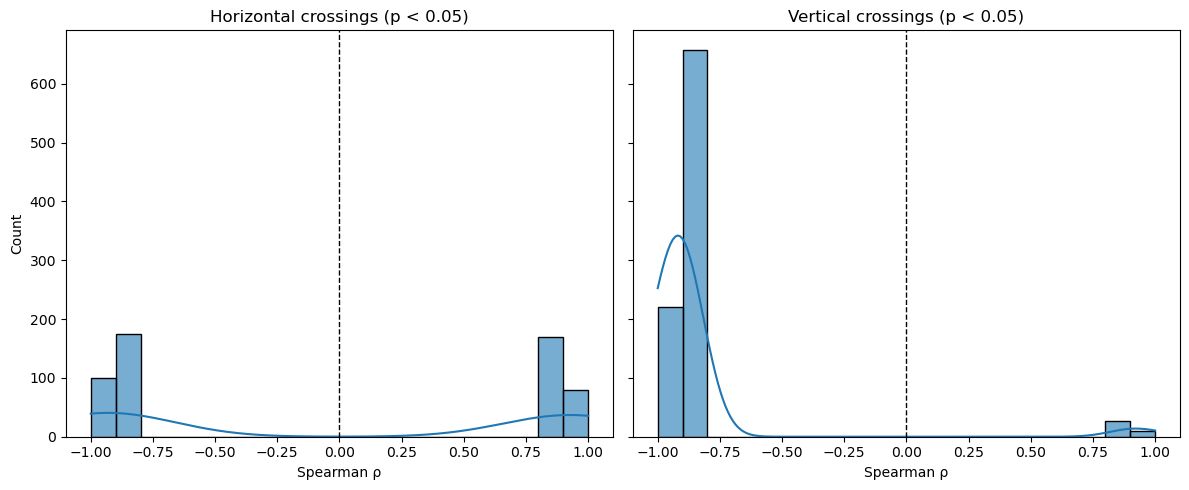

In [27]:
experiment_order = ['matrixRPA-WT-164', 'matrixRPA-WT-176', 'matrixRPA-WT-190', 'matrixRPA-WT-212', 'matrixRPA-WT-236']

# Compute Spearman correlations
spearman_df_rpa = compute_spearman_per_region(crossings_df_rpa, experiment_order)

# Plot histogram of significant correlations
plot_significant_spearman_histogram(spearman_df_rpa)


In [20]:
experiment_order_dmc1 = ['matrixDMC1-WT-164', 'matrixDMC1-WT-176', 'matrixDMC1-WT-190', 'matrixDMC1-WT-212', 'matrixDMC1-WT-236']
experiment_order = ['matrixRPA-WT-164', 'matrixRPA-WT-176', 'matrixRPA-WT-190', 'matrixRPA-WT-212', 'matrixRPA-WT-236']

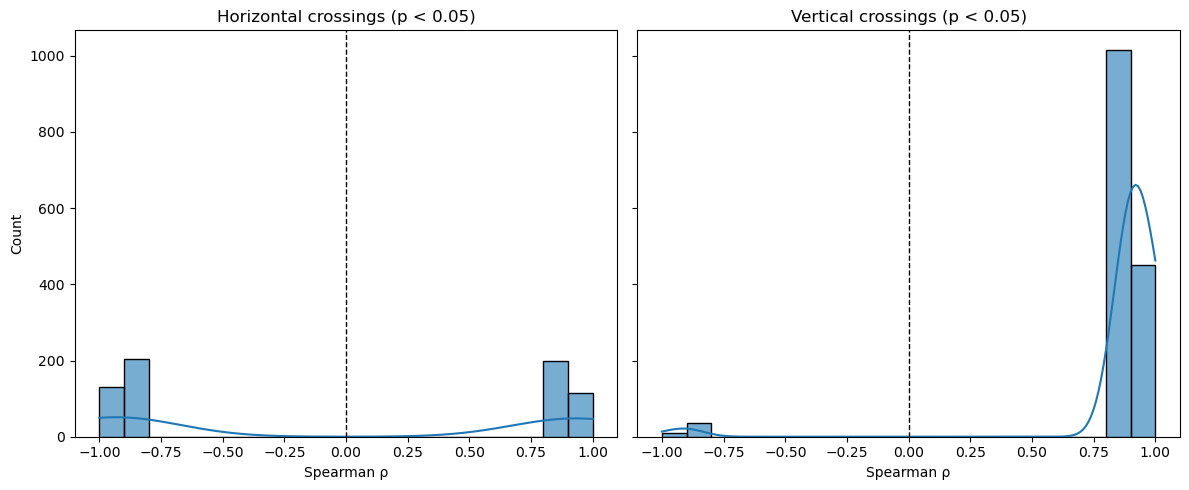

In [29]:
experiment_order_dmc1 = ['matrixDMC1-WT-164', 'matrixDMC1-WT-176', 'matrixDMC1-WT-190', 'matrixDMC1-WT-212', 'matrixDMC1-WT-236']

# Compute Spearman correlations
spearman_df_dmc1 = compute_spearman_per_region(crossings_df_dmc1, experiment_order_dmc1)

# Plot histogram of significant correlations
plot_significant_spearman_histogram(spearman_df_dmc1)


In [30]:
import matplotlib.pyplot as plt
import seaborn as sns

def plot_spearman_histograms(spearman_df):
    """
    Plot histograms and KDEs of Spearman ρ values for:
    - All correlations
    - Only those with p < 0.05
    Separately for horizontal and vertical.
    """
    fig, axes = plt.subplots(2, 2, figsize=(14, 10), sharex=True, sharey=True)

    for i, ctype in enumerate(['horizontal', 'vertical']):
        # All correlations
        all_subset = spearman_df[
            (spearman_df['type'] == ctype) &
            (~spearman_df['spearman_corr'].isna())
        ]
        sns.histplot(
            all_subset['spearman_corr'],
            bins=20,
            kde=True,
            stat="count",
            edgecolor='black',
            alpha=0.6,
            ax=axes[0, i]
        )
        axes[0, i].set_title(f"All {ctype} Spearman ρ")
        axes[0, i].axvline(0, color='black', linestyle='--')

        # Significant only (p < 0.05)
        sig_subset = all_subset[all_subset['p_value'] < 0.05]
        if not sig_subset.empty:
            sns.histplot(
                sig_subset['spearman_corr'],
                bins=20,
                kde=True,
                stat="count",
                edgecolor='black',
                alpha=0.6,
                ax=axes[1, i]
            )
        else:
            axes[1, i].text(0.5, 0.5, "No significant\ncorrelations", ha='center', va='center', fontsize=12)
            axes[1, i].set_xlim(-1, 1)

        axes[1, i].set_title(f"Significant {ctype} Spearman ρ (p < 0.05)")
        axes[1, i].axvline(0, color='black', linestyle='--')

        # Set axis labels
        for row in [0, 1]:
            axes[row, i].set_xlabel("Spearman ρ")
            axes[row, i].set_ylabel("Count")

    plt.tight_layout()
    plt.show()


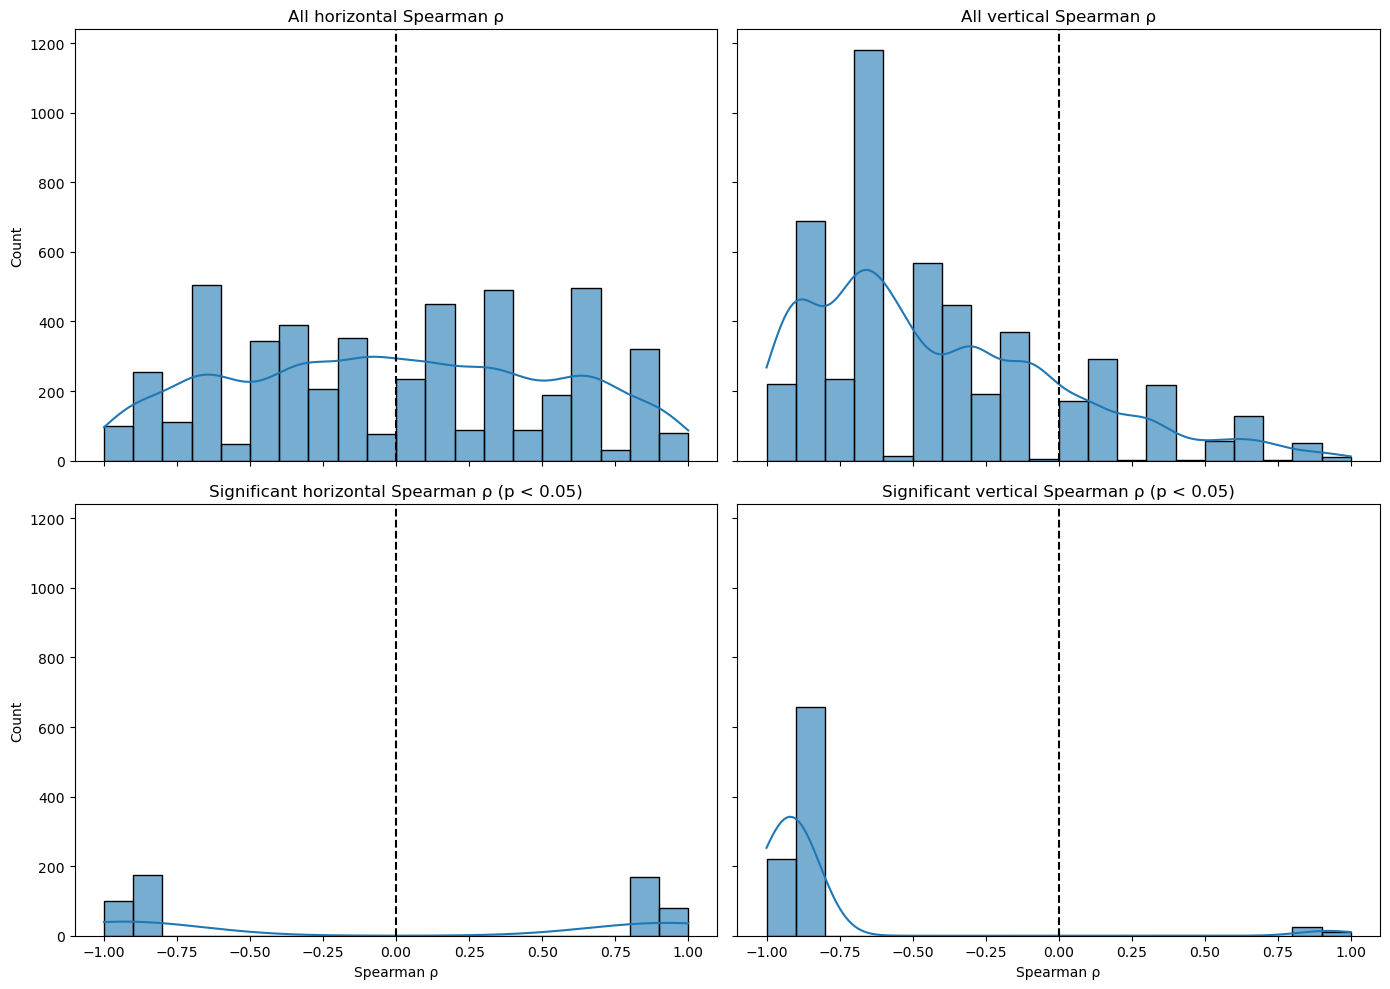

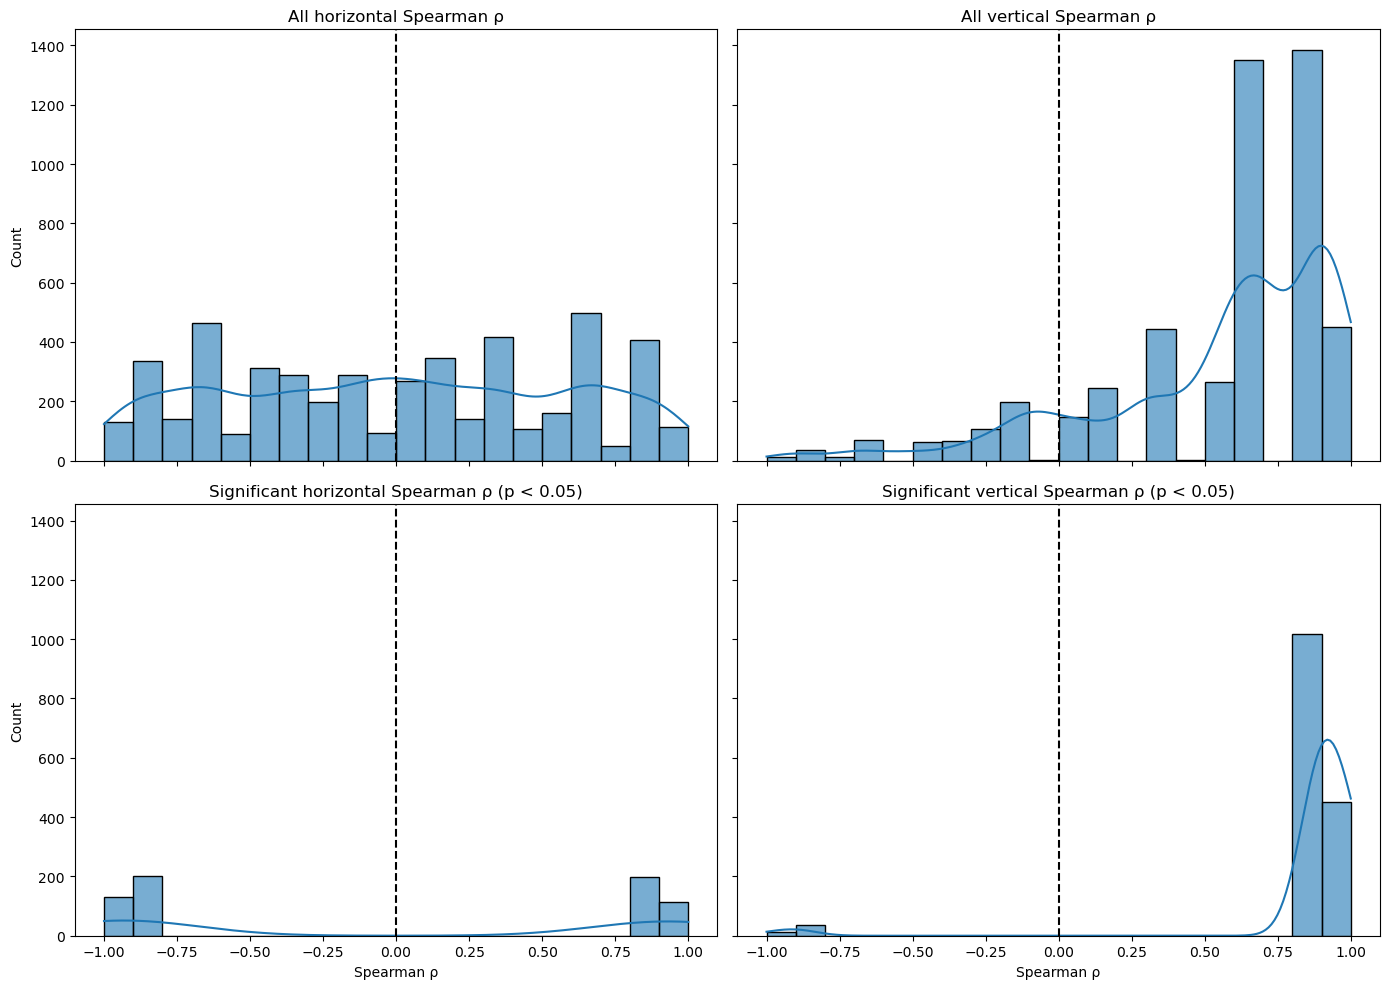

In [31]:
plot_spearman_histograms(spearman_df_rpa)
plot_spearman_histograms(spearman_df_dmc1)

In [32]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

def plot_crossing_trends(crossings_df, experiment_order):
    """
    Plot mean ± standard error of horizontal and vertical crossing values over time.

    Args:
        crossings_df: DataFrame with columns like horizontal_<exp>, vertical_<exp>
        experiment_order: list of experiment names in temporal order
    """
    fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharey=False)

    for ax, crossing_type in zip(axes, ['horizontal', 'vertical']):
        means = []
        sems = []

        for exp in experiment_order:
            col = f"{crossing_type}_{exp}"
            values = crossings_df[col].astype(float)
            mean = values.mean(skipna=True)
            sem = values.sem(skipna=True)
            means.append(mean)
            sems.append(sem)

        x = np.arange(len(experiment_order))
        means = np.array(means)
        sems = np.array(sems)

        ax.plot(x, means, label='Mean', marker='o', linestyle='-', linewidth=2)
        ax.fill_between(x, means - sems, means + sems, alpha=0.3, label='± SEM')
        ax.set_xticks(x)
        ax.set_xticklabels(experiment_order, rotation=45)
        ax.set_title(f"{crossing_type.capitalize()} Crossings Over Time")
        ax.set_ylabel("Crossing Value")
        ax.set_xlabel("Experiment")
        ax.axhline(0, color='black', linestyle='--', linewidth=1)
        ax.legend()

    plt.tight_layout()
    plt.show()


In [33]:
#plot_crossing_trends(crossings_df, experiment_order)


In [34]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

def plot_crossing_trends_scatter(crossings_df, experiment_order):
    """
    Plot mean ± SEM, median, and individual data points (scatter) for
    horizontal and vertical crossing values over time.

    Args:
        crossings_df: DataFrame with columns like horizontal_<exp>, vertical_<exp>
        experiment_order: list of experiment names in temporal order
    """
    fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharey=False)

    for ax, crossing_type in zip(axes, ['horizontal', 'vertical']):
        means, medians, sems = [], [], []

        for i, exp in enumerate(experiment_order):
            col = f"{crossing_type}_{exp}"
            values = crossings_df[col].astype(float)
            means.append(values.mean(skipna=True))
            medians.append(values.median(skipna=True))
            sems.append(values.sem(skipna=True))

            # Scatter: add jittered x-values for visual separation
            y_vals = values.dropna()
            jittered_x = np.random.normal(loc=i, scale=0.1, size=len(y_vals))
            ax.scatter(jittered_x, y_vals, alpha=0.4, color='gray', s=15, label='Region values' if i == 0 else None)

        x = np.arange(len(experiment_order))
        means = np.array(means)
        medians = np.array(medians)
        sems = np.array(sems)

        ax.plot(x, means, color ='darkblue', label='Mean', marker='o', linestyle='-', linewidth=2)
        #ax.fill_between(x, means - sems, means + sems, alpha=0.3, label='± SEM')
        ax.plot(x, medians, color = 'darkred', label='Median', marker='s', linestyle='--', linewidth=2)

        ax.set_xticks(x)
        ax.set_xticklabels(experiment_order, rotation=45)
        ax.set_title(f"{crossing_type.capitalize()} Crossings Over Time")
        ax.set_ylabel("Crossing Value")
        ax.set_xlabel("Timecourse")
        ax.axhline(0, color='black', linestyle='--', linewidth=1)
        ax.legend()

    plt.tight_layout()
    plt.show()

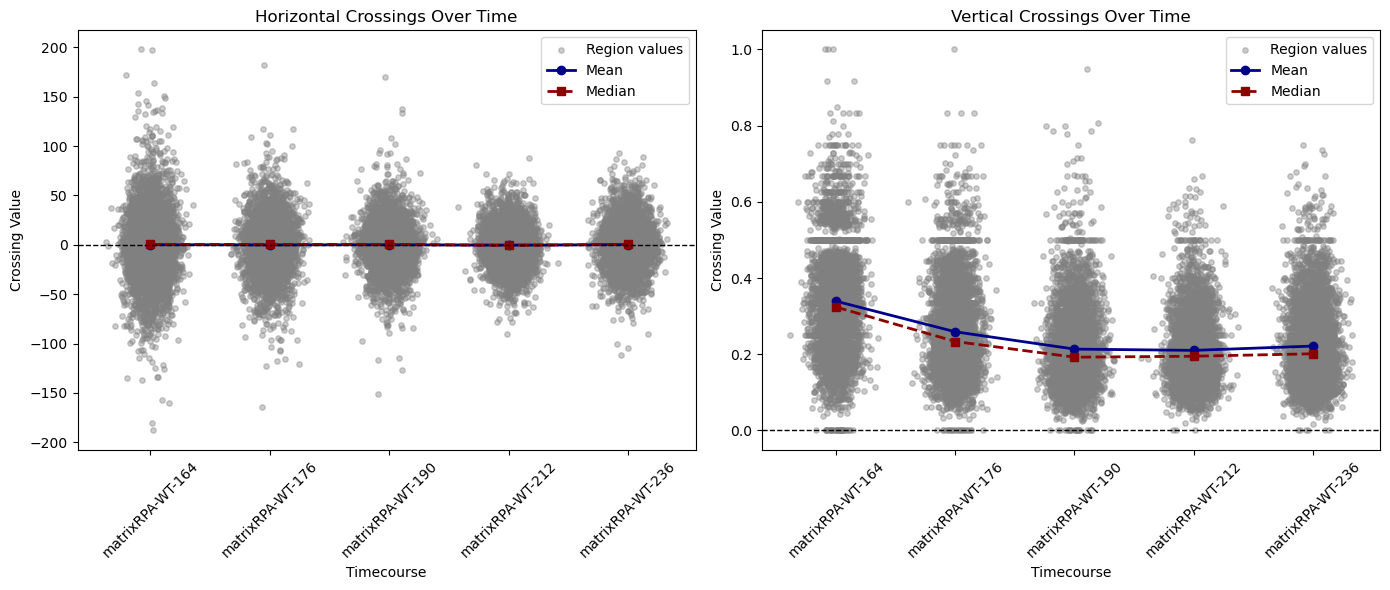

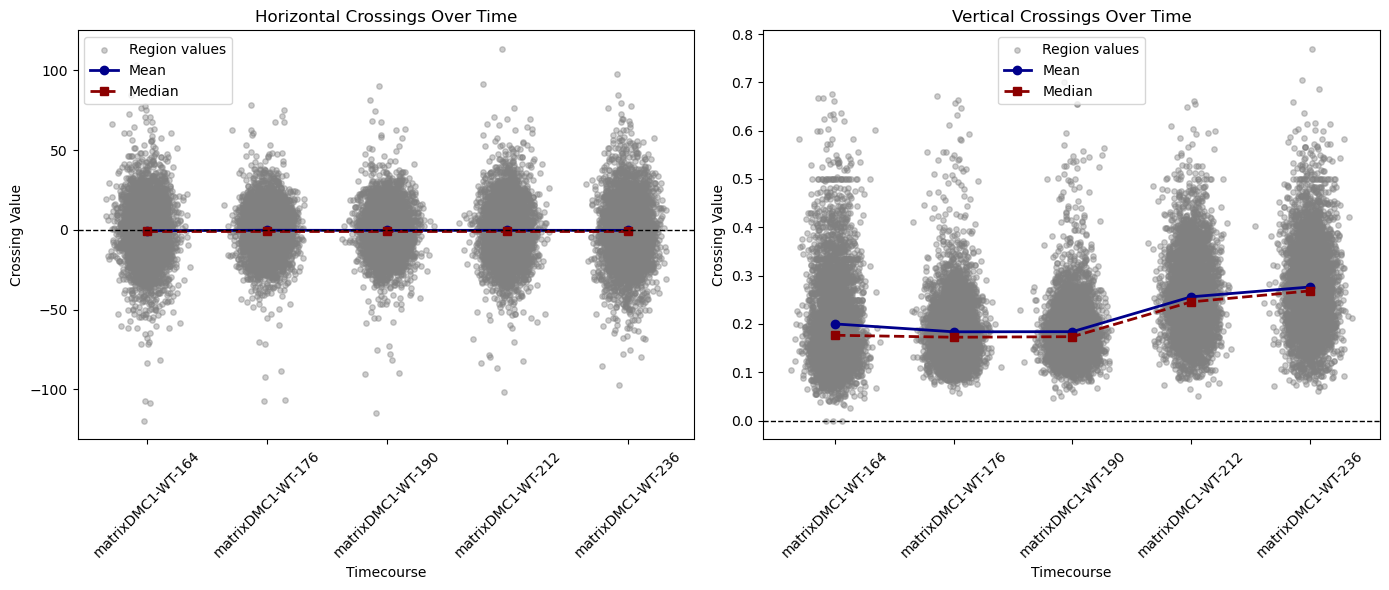

In [35]:
plot_crossing_trends_scatter(crossings_df_rpa, experiment_order)
plot_crossing_trends_scatter(crossings_df_dmc1, experiment_order_dmc1)

In [36]:
cumulative_dict

{'matrixDMC1-WT-164': {'forward':                               -200      -199      -198      -197      -196  \
  chr1:59358990-59359564         0.0       0.0       0.0       0.0       0.0   
  chr1:86088048-86088880         0.0       0.0       0.0       0.0       0.0   
  chr1:58419902-58420598         0.0       0.0       0.0       0.0       0.0   
  chr1:154652805-154653558       0.0       0.0       0.0       0.0       0.0   
  chr1:67961706-67963003    0.002956  0.005912  0.005912  0.005912  0.011824   
  ...                            ...       ...       ...       ...       ...   
  chrX:169971967-169972919       0.0       0.0  0.009662  0.009662  0.009662   
  chrX:111598605-111599624       0.0       0.0       0.0       0.0       0.0   
  chrX:112877308-112877827       0.0       0.0       0.0       0.0       0.0   
  chrX:88485240-88485848         0.0       0.0       0.0       0.0       0.0   
  chrX:152926272-152927072       0.0       0.0       0.0       0.0       0.0   
  
     

In [37]:
import matplotlib.pyplot as plt
import pandas as pd
import matplotlib.cm as cm
import numpy as np

def plot_overlayed_cumulative(cumulative_dict, experiment_order=None):
    """
    Overlay mean cumulative plots for forward and reverse strands across experiments.
    - Reverse strand: solid lines
    - Forward strand: dashed lines
    - Same color used for both lines of each experiment

    Args:
        cumulative_dict: dict of {experiment: {'forward': DataFrame, 'reverse': DataFrame}}
        experiment_order: Optional list to enforce consistent time ordering
    """
    if experiment_order is None:
        experiment_order = list(cumulative_dict.keys())

    plt.figure(figsize=(10, 6))

    # Set color map with consistent spacing
    cmap = cm.get_cmap('viridis', len(experiment_order))
    color_cycle = [cmap(i) for i in range(len(experiment_order))]

    for i, experiment in enumerate(experiment_order):
        forward_df = cumulative_dict[experiment]['forward']
        reverse_df = cumulative_dict[experiment]['reverse']

        forward_mean = forward_df.mean(axis=0, skipna=True)
        reverse_mean = reverse_df.mean(axis=0, skipna=True)
        x_vals = forward_mean.index.astype(float)

        color = color_cycle[i]

        # Reverse = solid, Forward = dashed
        plt.plot(x_vals, reverse_mean.values, label=f"{experiment} (forward)", linestyle='-', color=color)
        plt.plot(x_vals, forward_mean.values, label=f"{experiment} (reverse)", linestyle='--', color=color)

    plt.title("Mean Cumulative Signal (Forward & Reverse)")
    plt.xlabel("Position")
    plt.ylabel("Normalized Cumulative Signal")
    plt.axhline(0, color='black', linestyle='--', linewidth=1)
    plt.axhline(1, color='black', linestyle='--', linewidth=1)
    plt.legend()
    plt.grid()
    plt.yticks([0,0.1,0.2,0.3,0.4,0.5,0.6,0.7,0.8,0.9,1])
    plt.tight_layout()
    plt.show()


/scratch-local/slurm-job-tmp-8952058/ipykernel_98/4061750157.py:23: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  cmap = cm.get_cmap('viridis', len(experiment_order))


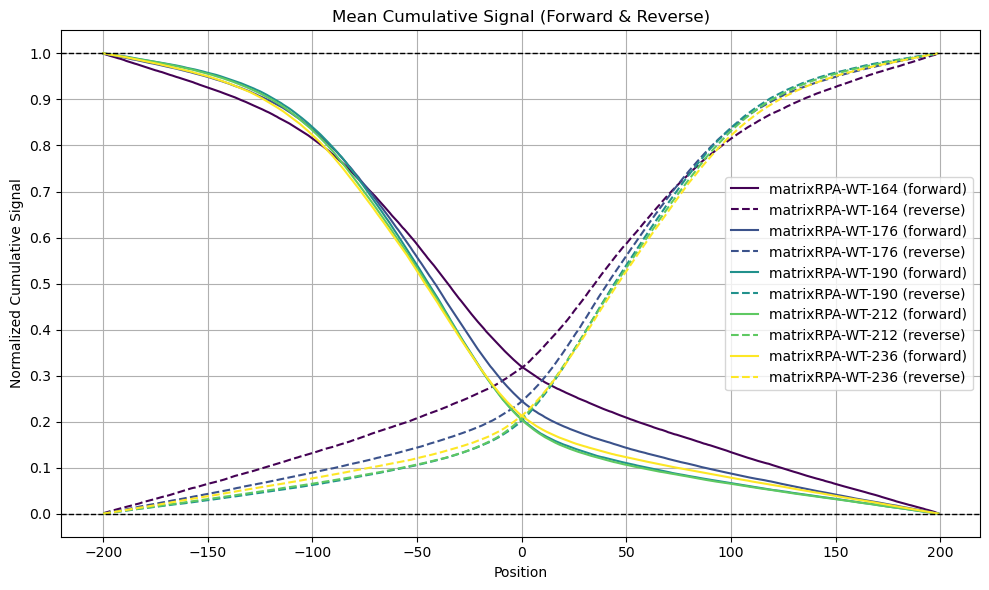

/scratch-local/slurm-job-tmp-8952058/ipykernel_98/4061750157.py:23: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  cmap = cm.get_cmap('viridis', len(experiment_order))


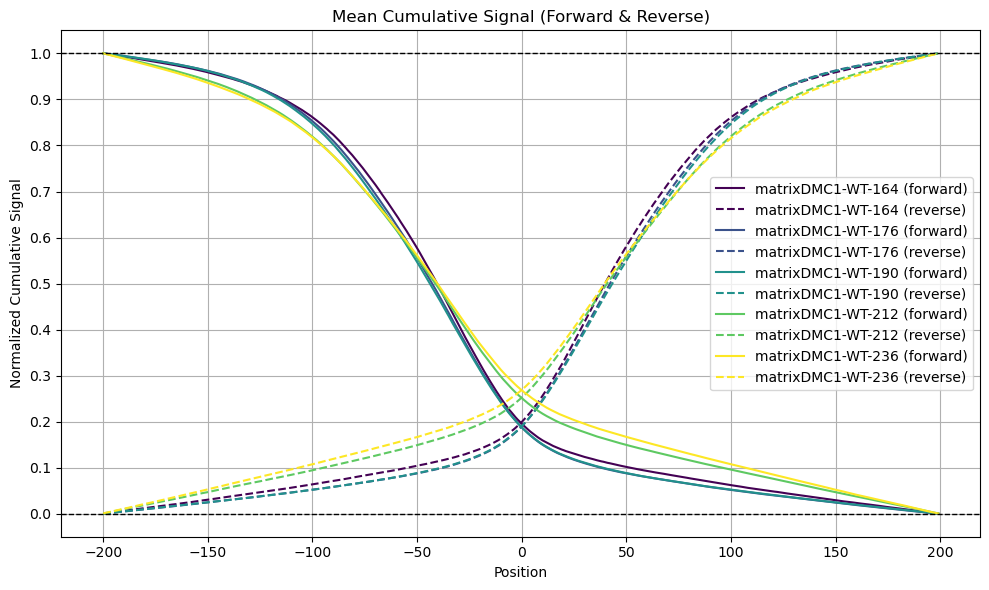

In [38]:
plot_overlayed_cumulative(cumulative_rpa_dict, experiment_order)
plot_overlayed_cumulative(cumulative_dmc1_dict, experiment_order_dmc1)

In [39]:
import matplotlib.pyplot as plt
import pandas as pd
import matplotlib.cm as cm
import numpy as np

def plot_overlayed_coverage(cumulative_dict, experiment_order=None):
    """
    Overlay mean cumulative plots for forward and reverse strands across experiments.
    - Reverse strand: solid lines
    - Forward strand: dashed lines
    - Same color used for both lines of each experiment

    Args:
        cumulative_dict: dict of {experiment: {'forward': DataFrame, 'reverse': DataFrame}}
        experiment_order: Optional list to enforce consistent time ordering
    """
    if experiment_order is None:
        experiment_order = list(cumulative_dict.keys())

    plt.figure(figsize=(10, 6))

    # Set color map with consistent spacing
    cmap = cm.get_cmap('viridis', len(experiment_order))
    color_cycle = [cmap(i) for i in range(len(experiment_order))]

    for i, experiment in enumerate(experiment_order):
        forward_df = cumulative_dict[experiment]['forward'].iloc[:, :-1]
        reverse_df = cumulative_dict[experiment]['reverse'].iloc[:, :-1]

        forward_mean = forward_df.mean(axis=0, skipna=True)
        #forward_mean /= np.sum(forward_mean)
        forward_mean = forward_mean.rolling(window=15, center=True).mean()
        reverse_mean = reverse_df.mean(axis=0, skipna=True)
        #reverse_mean /= np.sum(reverse_mean)
        reverse_mean =  reverse_mean.rolling(window=15, center=True).mean()
        x_vals = forward_mean.index.astype(float)

        color = color_cycle[i]

        # Reverse = solid, Forward = dashed
        plt.plot(x_vals, reverse_mean.values, label=f"{experiment} (forward)", linestyle='-', color=color)
        plt.plot(x_vals, forward_mean.values, label=f"{experiment} (reverse)", linestyle='--', color=color)

    plt.title("Mean Coverage Signal (Forward & Reverse)")
    plt.xlabel("Position")
    #plt.ylabel("Normalized Cumulative Signal")
    plt.axhline(0, color='black', linestyle='--', linewidth=1)
    #plt.axhline(1, color='black', linestyle='--', linewidth=1)
    plt.legend()
    plt.grid()
    #plt.ylim(0,0.2)
    #plt.yticks([0,0.1,0.2])
    plt.tight_layout()
    plt.show()


In [17]:
# Split the cumulative_dict into RPA and DMC1 based on experiment name
dict_mat_rpa = {k: v for k, v in dict_mat.items() if 'RPA' in k}
dict_mat_dmc1 = {k: v for k, v in dict_mat.items() if 'DMC1' in k}


/scratch-local/slurm-job-tmp-8952058/ipykernel_98/1248083267.py:23: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  cmap = cm.get_cmap('viridis', len(experiment_order))


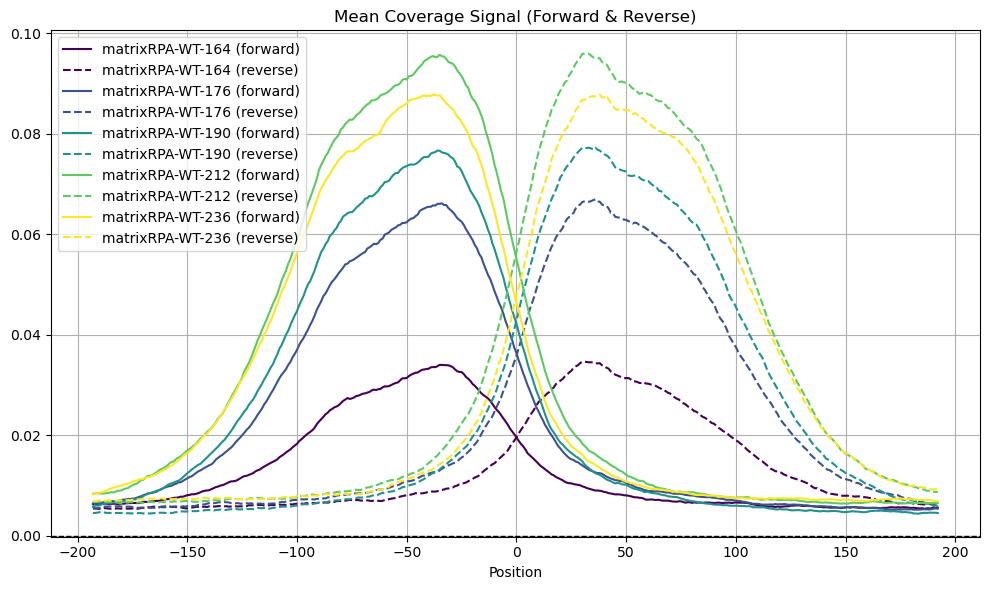

/scratch-local/slurm-job-tmp-8952058/ipykernel_98/1248083267.py:23: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  cmap = cm.get_cmap('viridis', len(experiment_order))


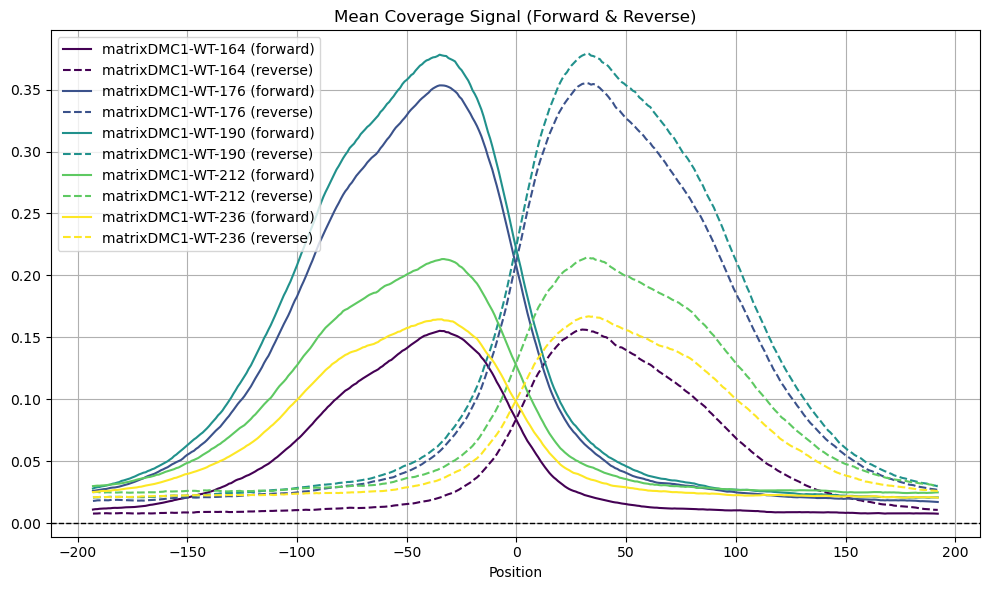

In [41]:
plot_overlayed_coverage(dict_mat_rpa, experiment_order)
plot_overlayed_coverage(dict_mat_dmc1, experiment_order_dmc1)

In [54]:
def plot_overlayed_coverage_with_background_subtraction(cumulative_dict, experiment_order=None):
    """
    Overlay mean cumulative plots with background subtraction for forward and reverse strands.

    Reverse strand background: mean of columns 150 to 200
    Forward strand background: mean of columns -200 to -150

    - Reverse strand: solid lines
    - Forward strand: dashed lines
    - Same color used for both lines of each experiment

    Args:
        cumulative_dict: dict of {experiment: {'forward': DataFrame, 'reverse': DataFrame}}
        experiment_order: Optional list to enforce consistent time ordering
    """
    if experiment_order is None:
        experiment_order = list(cumulative_dict.keys())

    plt.figure(figsize=(10, 6))

    cmap = cm.get_cmap('viridis', len(experiment_order))
    color_cycle = [cmap(i) for i in range(len(experiment_order))]

    for i, experiment in enumerate(experiment_order):
        forward_df = cumulative_dict[experiment]['forward'].iloc[:, :-1]
        reverse_df = cumulative_dict[experiment]['reverse'].iloc[:, :-1]

        # Reverse: subtract mean of columns 150 to 200
        reverse_bg = reverse_df.iloc[:, 100:200].mean(axis=1, skipna=True)
        reverse_df_bgsub = reverse_df.sub(reverse_bg, axis=0).clip(lower=0)
        #reverse_bg = reverse_df.iloc[:, 199:201].mean(axis=1, skipna=True)
        #reverse_df_bgsub = reverse_df.subtract(reverse_bg, axis=0)
        reverse_mean = reverse_df_bgsub.mean(axis=0, skipna=True)
        reverse_mean = reverse_mean.rolling(window=15, center=True).mean()
        #reverse_mean /= np.sum(reverse_mean)
        # Reverse: subtract background, clip at zero
        


        # Forward: subtract mean of columns -200 to -150
        forward_bg = forward_df.iloc[:, -200:-100].mean(axis=1, skipna=True)
        forward_df_bgsub = forward_df.sub(forward_bg, axis=0).clip(lower=0)
        #forward_bg = forward_df.iloc[:, -200:-199].mean(axis=1, skipna=True)
        #forward_df_bgsub = forward_df.subtract(forward_bg, axis=0)
        forward_mean = forward_df_bgsub.mean(axis=0, skipna=True)
        forward_mean = forward_mean.rolling(window=15, center=True).mean()
        #forward_mean /= np.sum(forward_mean)

        x_vals = forward_mean.index.astype(float)
        color = color_cycle[i]

        # Reverse = solid, Forward = dashed
        plt.plot(x_vals, reverse_mean.values, label=f"{experiment} (forward)", linestyle='-', color=color)
        plt.plot(x_vals, forward_mean.values, label=f"{experiment} (reverse)", linestyle='--', color=color)

    plt.axhline(0, color='black', linestyle='--', linewidth=1)
    plt.legend()
    plt.grid()
    plt.tight_layout()
    plt.show()


In [80]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import cm

def _to_numeric_index(xindex):
    """Safely convert an Index of positions to float array (NaNs if uncastable)."""
    # Works for numeric, stringified numeric, Int64Index, RangeIndex, etc.
    return pd.to_numeric(pd.Index(xindex), errors='coerce').to_numpy()

def plot_overlayed_coverage_with_background_subtraction_zeroed(cumulative_dict, experiment_order=None):
    """
    Overlay mean cumulative plots with background subtraction for forward and reverse strands.

    Reverse strand background: mean of columns 100 to 200 (positional window)
    Forward strand background: mean of columns -200 to -100 (positional window)

    After smoothing, set the profile to 0 at:
      - Reverse: x in [100, 200]
      - Forward: x in [-200, -100]

    - Reverse strand: solid lines
    - Forward strand: dashed lines
    - Same color used for both lines of each experiment

    Args:
        cumulative_dict: dict of {experiment: {'forward': DataFrame, 'reverse': DataFrame}}
                         DataFrame columns should be position labels (e.g., -500..500).
        experiment_order: Optional list to enforce consistent time ordering
    """
    if experiment_order is None:
        experiment_order = list(cumulative_dict.keys())

    plt.figure(figsize=(10, 6))
    cmap = cm.get_cmap('viridis', len(experiment_order))
    color_cycle = [cmap(i) for i in range(len(experiment_order))]

    for i, experiment in enumerate(experiment_order):
        # Drop the last column if it’s metadata, as in your code
        forward_df = cumulative_dict[experiment]['forward'].iloc[:, :-1]
        reverse_df = cumulative_dict[experiment]['reverse'].iloc[:, :-1]

        # -------- Background subtraction (positional windows, as you had) --------
        # Reverse: mean of columns 100:200 (positional slice)
        reverse_bg = reverse_df.iloc[:, -200:-150].mean(axis=1, skipna=True)
        reverse_df_bgsub = reverse_df.sub(reverse_bg, axis=0)

        # Forward: mean of columns -200:-100 (positional slice from the end)
        forward_bg = forward_df.iloc[:, 150:200].mean(axis=1, skipna=True)
        print(forward_bg)
        forward_df_bgsub = forward_df.sub(forward_bg, axis=0)

        # -------- Mean across samples + smoothing --------
        reverse_mean = reverse_df_bgsub.mean(axis=0) #mean(axis=0, skipna=True).rolling(window=1, center=True).mean()
        forward_mean = forward_df_bgsub.mean(axis=0) #mean(axis=0, skipna=True).rolling(window=1, center=True).mean()

        # -------- Zero out by *label ranges* (not positional) --------
        # Convert indices (positions) to numeric arrays
        x_rev = _to_numeric_index(reverse_mean.index)
        x_fwd = _to_numeric_index(forward_mean.index)

        # Masks for your requested position ranges
        rev_mask = (x_rev >= 100) & (x_rev <= 200)
        fwd_mask = (x_fwd >= -200) & (x_fwd <= -100)

        # Set those ranges to zero explicitly
        # (Use .values to avoid index alignment issues with boolean masks of same length)
        r_vals = reverse_mean.values.copy()
        f_vals = forward_mean.values.copy()
        #r_vals[rev_mask] = 0.0
        #f_vals[fwd_mask] = 0.0

        # Optional: if smoothing produced NaNs (edges), turn NaNs to 0 just within the mask
        # r_vals[np.isnan(r_vals) & rev_mask] = 0.0
        # f_vals[np.isnan(f_vals) & fwd_mask] = 0.0

        color = color_cycle[i]

        # Plot with corrected labels: reverse=solid, forward=dashed
        plt.plot(x_rev, r_vals, label=f"{experiment} (forward)", linestyle='-',  color=color)
        plt.plot(x_fwd, f_vals, label=f"{experiment} (reverse)", linestyle='--', color=color)

    plt.axhline(0, color='black', linestyle='--', linewidth=1)
    plt.legend()
    plt.grid()
    plt.tight_layout()
    plt.show()


/scratch-local/slurm-job-tmp-9148143/ipykernel_169/2497095241.py:35: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  cmap = cm.get_cmap('viridis', len(experiment_order))


chr1:59358990-59359564      0.006667
chr1:86088048-86088880      0.013333
chr1:58419902-58420598      0.020000
chr1:154652805-154653558    0.013333
chr1:67961706-67963003      0.073333
                              ...   
chrX:169971967-169972919    0.006667
chrX:111598605-111599624    0.000000
chrX:112877308-112877827    0.013333
chrX:88485240-88485848      0.000000
chrX:152926272-152927072    0.000000
Length: 4851, dtype: float64
chr1:59358990-59359564      0.006667
chr1:86088048-86088880      0.080000
chr1:58419902-58420598      0.060000
chr1:154652805-154653558    0.000000
chr1:67961706-67963003      0.153333
                              ...   
chrX:169971967-169972919    0.026667
chrX:111598605-111599624    0.000000
chrX:112877308-112877827    0.006667
chrX:88485240-88485848      0.000000
chrX:152926272-152927072    0.020000
Length: 4851, dtype: float64
chr1:59358990-59359564      0.006667
chr1:86088048-86088880      0.046667
chr1:58419902-58420598      0.086667
chr1:154652805-15

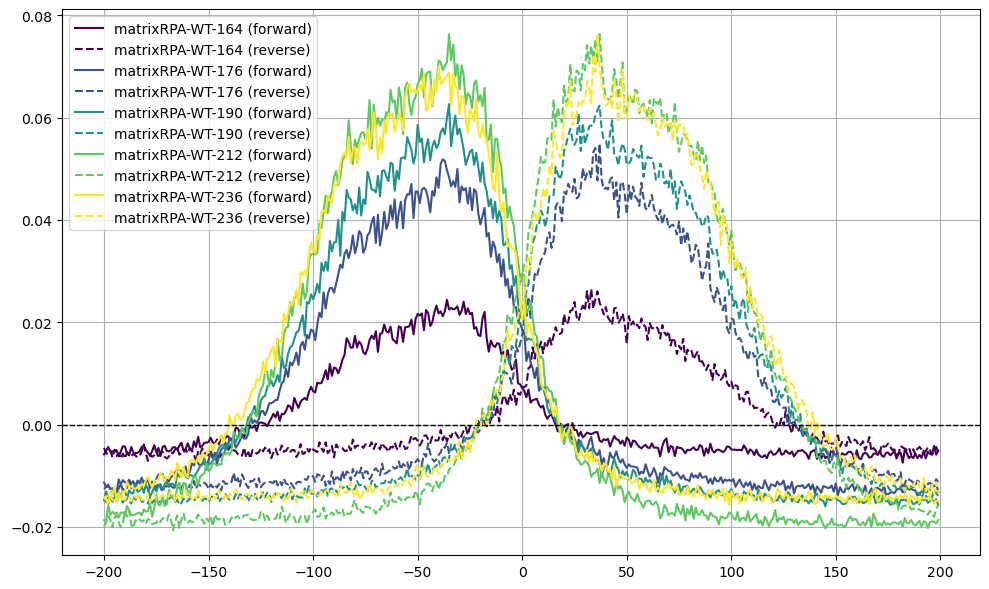

/scratch-local/slurm-job-tmp-9148143/ipykernel_169/2497095241.py:35: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  cmap = cm.get_cmap('viridis', len(experiment_order))


chr1:59358990-59359564      0.013333
chr1:86088048-86088880      0.106667
chr1:58419902-58420598      0.133333
chr1:154652805-154653558    0.013333
chr1:67961706-67963003      0.344444
                              ...   
chrX:169971967-169972919    0.073333
chrX:111598605-111599624    0.026667
chrX:112877308-112877827    0.020000
chrX:88485240-88485848      0.006667
chrX:152926272-152927072    0.006667
Length: 4851, dtype: float64
chr1:59358990-59359564      0.046667
chr1:86088048-86088880      0.292222
chr1:58419902-58420598      0.299333
chr1:154652805-154653558    0.026667
chr1:67961706-67963003      0.634016
                              ...   
chrX:169971967-169972919    0.140000
chrX:111598605-111599624    0.026667
chrX:112877308-112877827    0.033333
chrX:88485240-88485848      0.020000
chrX:152926272-152927072    0.000000
Length: 4851, dtype: float64
chr1:59358990-59359564      0.053333
chr1:86088048-86088880      0.240000
chr1:58419902-58420598      0.328000
chr1:154652805-15

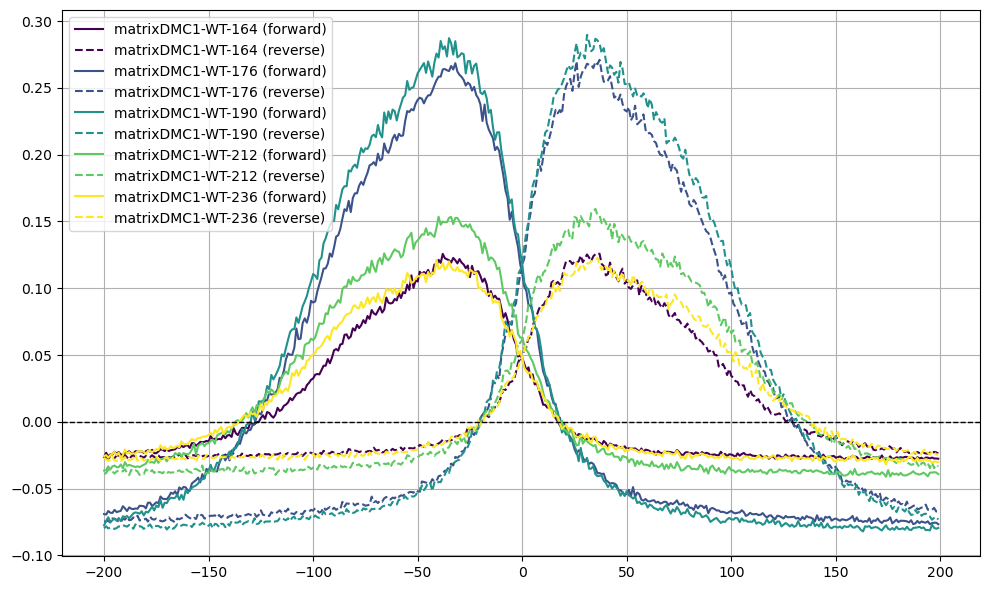

In [81]:
plot_overlayed_coverage_with_background_subtraction_zeroed(dict_mat_rpa, experiment_order)
plot_overlayed_coverage_with_background_subtraction_zeroed(dict_mat_dmc1, experiment_order_dmc1)

In [31]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import cm

def _to_numeric_index(index):
    """Convert column labels to numeric positions (works for numeric/strings)."""
    return pd.to_numeric(pd.Index(index), errors='coerce')

def plot_overlayed_cumulative_bgsub(
    cumulative_dict,
    experiment_order=None,
    # BG windows by *position in the matrix* (positional slice, like .iloc)
    reverse_bg_pos=(100, 200),     # use columns 100:200
    forward_bg_pos=(-200, -100),   # use columns -200:-100 (from the end)
    # Label ranges to set to zero in the final profile (by x-label values)
    reverse_zero_label=(100, 200),
    forward_zero_label=(-200, -100),
    smooth_window=15,              # set 0/None to disable smoothing
    zero_out_background=True,      # zero the above label ranges after smoothing
    normalize=True                # normalize each profile to max=1 after processing
):
    """
    Plot mean cumulative profiles AFTER background subtraction.

    Steps per experiment & strand:
      1) Subtract row-wise mean over the background positional window
      2) Clip negatives to 0
      3) Mean across rows (replicates)
      4) Optional smoothing (rolling centered)
      5) Optional zeroing by *label range* (x in [low, high])
      6) Optional normalization to [0,1]
      7) Plot (reverse=solid, forward=dashed)

    Args:
        cumulative_dict: {experiment: {'forward': DataFrame, 'reverse': DataFrame}}
                         Columns should represent genomic positions (labels convertible to numeric).
        experiment_order: plotting order of experiments (defaults to dict keys order)
        reverse_bg_pos: tuple (start, end) positional columns for reverse background (like .iloc[:, start:end])
        forward_bg_pos: tuple (start, end) positional columns for forward background (like .iloc[:, start:end])
        reverse_zero_label: (low, high) label range to set to 0 in the reverse profile (by x label values)
        forward_zero_label: (low, high) label range to set to 0 in the forward profile (by x label values)
        smooth_window: rolling window size (centered). Use None or 0 to disable.
        zero_out_background: if True, set values in the above label ranges to 0 after smoothing
        normalize: if True, scale each plotted profile to its own max so y∈[0,1]
    """
    if experiment_order is None:
        experiment_order = list(cumulative_dict.keys())

    plt.figure(figsize=(10, 6))
    cmap = cm.get_cmap('viridis', len(experiment_order))
    color_cycle = [cmap(i) for i in range(len(experiment_order))]

    for i, experiment in enumerate(experiment_order):
        fwd_df = cumulative_dict[experiment]['forward']
        rev_df = cumulative_dict[experiment]['reverse']

        # ---- Background subtraction (positional windows) + clip to zero
        r_start, r_end = reverse_bg_pos
        f_start, f_end = forward_bg_pos

        rev_bg = rev_df.iloc[:, r_start:r_end].mean(axis=1, skipna=True)
        fwd_bg = fwd_df.iloc[:, f_start:f_end].mean(axis=1, skipna=True)

        rev_bgsub = rev_df.sub(rev_bg, axis=0).clip(lower=0)
        fwd_bgsub = fwd_df.sub(fwd_bg, axis=0).clip(lower=0)

        # ---- Mean across replicates
        rev_mean = rev_bgsub.mean(axis=0, skipna=True)
        fwd_mean = fwd_bgsub.mean(axis=0, skipna=True)

        # ---- Optional smoothing
        if smooth_window and smooth_window > 1:
            rev_mean = rev_mean.rolling(window=smooth_window, center=True, min_periods=1).mean()
            fwd_mean = fwd_mean.rolling(window=smooth_window, center=True, min_periods=1).mean()

        # ---- Zero out by *label ranges* (x-labels), if requested
        x_rev = _to_numeric_index(rev_mean.index)
        x_fwd = _to_numeric_index(fwd_mean.index)

        # Keep only positions we can interpret
        valid_rev = ~x_rev.isna()
        valid_fwd = ~x_fwd.isna()

        rev_vals = rev_mean.values.astype(float).copy()
        fwd_vals = fwd_mean.values.astype(float).copy()

        if zero_out_background:
            rl, rh = reverse_zero_label
            fl, fh = forward_zero_label
            rev_mask = valid_rev & (x_rev.to_numpy() >= rl) & (x_rev.to_numpy() <= rh)
            fwd_mask = valid_fwd & (x_fwd.to_numpy() >= fl) & (x_fwd.to_numpy() <= fh)
            rev_vals[rev_mask] = 0.0
            fwd_vals[fwd_mask] = 0.0

        # ---- Optional normalization per profile
        if normalize:
            r_max = np.nanmax(rev_vals) if np.any(np.isfinite(rev_vals)) else 1.0
            f_max = np.nanmax(fwd_vals) if np.any(np.isfinite(fwd_vals)) else 1.0
            if r_max > 0: rev_vals = rev_vals / r_max
            if f_max > 0: fwd_vals = fwd_vals / f_max

        color = color_cycle[i]
        # Plot with correct labels: reverse=solid, forward=dashed
        plt.plot(x_rev[valid_rev], rev_vals[valid_rev], label=f"{experiment} (forward)", linestyle='-',  color=color)
        plt.plot(x_fwd[valid_fwd], fwd_vals[valid_fwd], label=f"{experiment} (reverse)", linestyle='--', color=color)

    plt.title("Mean Cumulative Signal after Background Subtraction")
    plt.xlabel("Position")
    plt.ylabel("Cumulative Signal" + (" (normalized)" if normalize else ""))
    plt.axhline(0, color='black', linestyle='--', linewidth=1)

    # Use 0..1 ticks only when normalized
    if normalize:
        plt.yticks([0,0.1,0.2,0.3,0.4,0.5,0.6,0.7,0.8,0.9,1])

    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()


In [35]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import cm

# 1) Background subtraction ----------------------------------------------------
def bg_subtract_coverage(
    dict_mat,
    reverse_bg_pos=(100, 200),   # .iloc positional slice: use columns 100:200 for reverse
    forward_bg_pos=(-200, -100), # .iloc positional slice: use columns -200:-100 for forward
    drop_last_col=True           # drop a trailing dummy column, if present
):
    """
    Row-wise background subtraction per experiment, per strand.
    For each row: signal := max(signal - bg, 0), where bg is the row-mean over the background window.

    Args:
        dict_mat: {experiment: {'forward': DataFrame, 'reverse': DataFrame}}
        reverse_bg_pos: (start, end) positional columns for reverse strand background window
        forward_bg_pos: (start, end) positional columns for forward strand background window
        drop_last_col: if True, drop the last column (e.g., dummy/metadata)

    Returns:
        dict of same structure with background-subtracted DataFrames.
    """
    out = {}
    for exp, mats in dict_mat.items():
        fwd = mats['forward']
        rev = mats['reverse']
        if drop_last_col:
            fwd = fwd.iloc[:, :-1]
            rev = rev.iloc[:, :-1]

        # Reverse background: mean over positional slice
        r_s, r_e = reverse_bg_pos
        rev_bg = rev.iloc[:, r_s:r_e].mean(axis=1, skipna=True)
        rev_bgsub = rev.sub(rev_bg, axis=0).clip(lower=0)

        # Forward background: mean over positional slice
        f_s, f_e = forward_bg_pos
        fwd_bg = fwd.iloc[:, f_s:f_e].mean(axis=1, skipna=True)
        fwd_bgsub = fwd.sub(fwd_bg, axis=0).clip(lower=0)

        out[exp] = {'forward': fwd_bgsub, 'reverse': rev_bgsub}
    return out


# 2) Cumulative from bg-subtracted coverage -----------------------------------
def compute_cumulative_from_bgsub(
    dict_bgsub,
    output_dir=None,
    forward_direction="left_to_right",   # <-- swapped: forward L->R
    reverse_direction="right_to_left",   # <-- swapped: reverse R->L
    save_csv=True
):
    """
    Compute cumulative matrices FROM background-subtracted coverage.

    Directions:
      - Forward:  left_to_right   -> s.cumsum()
      - Reverse:  right_to_left   -> s[::-1].cumsum()[::-1]

    Each row is normalized to 1:
      - For left_to_right cumulative, divide by the last element of the cumulative row.
      - For right_to_left cumulative, divide by the first element of the cumulative row.
    """
    if output_dir:
        os.makedirs(output_dir, exist_ok=True)

    def _cumulate_row(s: pd.Series, direction: str) -> pd.Series:
        if direction == "right_to_left":
            c = s[::-1].cumsum()[::-1]
            total = c.iloc[0]
            return c / (total if total != 0 else 1.0)
        elif direction == "left_to_right":
            c = s.cumsum()
            total = c.iloc[-1]
            return c / (total if total != 0 else 1.0)
        else:
            raise ValueError("direction must be 'right_to_left' or 'left_to_right'")

    cumulative_dict = {}
    for exp, mats in dict_bgsub.items():
        fwd = mats['forward']
        rev = mats['reverse']

        fwd_cum = pd.DataFrame(index=fwd.index, columns=fwd.columns, dtype=float)
        rev_cum = pd.DataFrame(index=rev.index, columns=rev.columns, dtype=float)

        for idx in fwd.index:
            fwd_cum.loc[idx] = _cumulate_row(fwd.loc[idx], forward_direction)
        for idx in rev.index:
            rev_cum.loc[idx] = _cumulate_row(rev.loc[idx], reverse_direction)

        if output_dir and save_csv:
            fwd_path = os.path.join(output_dir, f"{exp}_forward_cumulative.csv")
            rev_path = os.path.join(output_dir, f"{exp}_reverse_cumulative.csv")
            fwd_cum.to_csv(fwd_path)
            rev_cum.to_csv(rev_path)
            print(f"[✓] Saved: {fwd_path}")
            print(f"[✓] Saved: {rev_path}")

        cumulative_dict[exp] = {'forward': fwd_cum, 'reverse': rev_cum}

    return cumulative_dict


# 3) Plot overlayed mean cumulative (from bg-subtracted coverage) --------------
def plot_overlayed_cumulative_from_bgsub(
    cumulative_dict,
    experiment_order=None,
    title="Mean Cumulative Signal (after BG subtraction)",
    normalize_ticks_to_0_1=True
):
    """
    Overlay mean cumulative plots (reverse solid, forward dashed) per experiment.
    """
    if experiment_order is None:
        experiment_order = list(cumulative_dict.keys())

    plt.figure(figsize=(10, 6))
    cmap = cm.get_cmap('viridis', len(experiment_order))
    color_cycle = [cmap(i) for i in range(len(experiment_order))]

    for i, exp in enumerate(experiment_order):
        fwd_df = cumulative_dict[exp]['forward']
        rev_df = cumulative_dict[exp]['reverse']

        fwd_mean = fwd_df.mean(axis=0, skipna=True)
        rev_mean = rev_df.mean(axis=0, skipna=True)

        # x-axis: cast column labels to numeric if possible
        try:
            x_vals = fwd_mean.index.astype(float)
        except Exception:
            x_vals = pd.to_numeric(fwd_mean.index, errors='coerce')

        color = color_cycle[i]

        # Plot with correct labels: reverse = solid, forward = dashed
        plt.plot(x_vals, rev_mean.values.astype(float), label=f"{exp} (reverse)", linestyle='--',  color=color)
        plt.plot(x_vals, fwd_mean.values.astype(float), label=f"{exp} (forward)", linestyle='-', color=color)

    plt.title(title)
    plt.xlabel("Position")
    plt.ylabel("Cumulative Signal")
    plt.axhline(0, color='black', linestyle='--', linewidth=1)
    if normalize_ticks_to_0_1:
        plt.yticks([0,0.1,0.2,0.3,0.4,0.5,0.6,0.7,0.8,0.9,1])
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()


[✓] Saved: cumulative_csvs/matrixRPA-WT-164_forward_cumulative.csv
[✓] Saved: cumulative_csvs/matrixRPA-WT-164_reverse_cumulative.csv
[✓] Saved: cumulative_csvs/matrixRPA-WT-176_forward_cumulative.csv
[✓] Saved: cumulative_csvs/matrixRPA-WT-176_reverse_cumulative.csv
[✓] Saved: cumulative_csvs/matrixRPA-WT-190_forward_cumulative.csv
[✓] Saved: cumulative_csvs/matrixRPA-WT-190_reverse_cumulative.csv
[✓] Saved: cumulative_csvs/matrixRPA-WT-212_forward_cumulative.csv
[✓] Saved: cumulative_csvs/matrixRPA-WT-212_reverse_cumulative.csv
[✓] Saved: cumulative_csvs/matrixRPA-WT-236_forward_cumulative.csv
[✓] Saved: cumulative_csvs/matrixRPA-WT-236_reverse_cumulative.csv


/scratch-local/slurm-job-tmp-9148143/ipykernel_169/2572031370.py:123: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  cmap = cm.get_cmap('viridis', len(experiment_order))


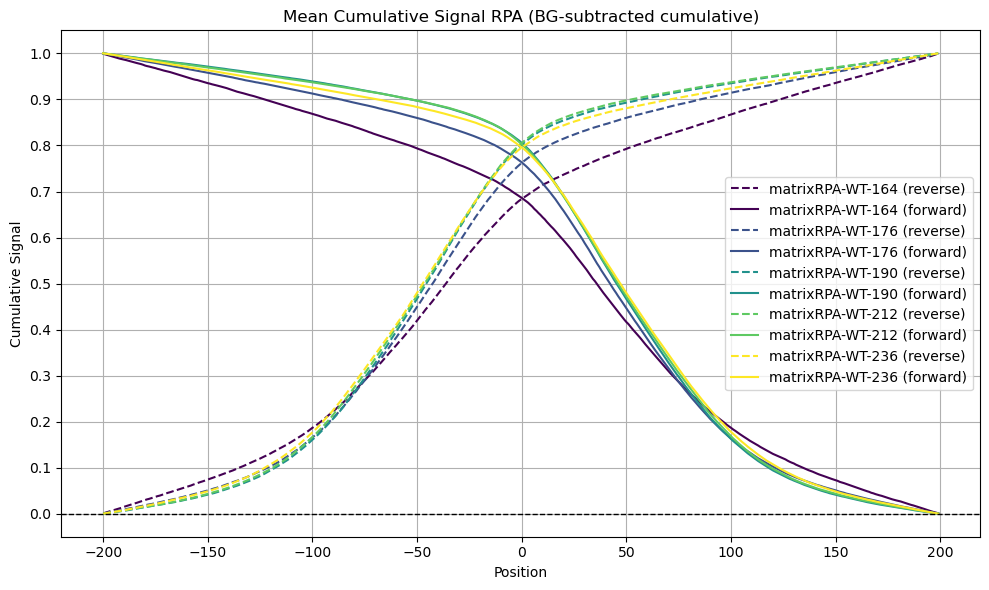

In [36]:
# Step 1: BG subtraction on your raw coverage matrices
bgsub = bg_subtract_coverage(
    dict_mat_rpa,
    reverse_bg_pos=(100, 200),
    forward_bg_pos=(-200, -100),
    drop_last_col=True
)

# Step 2: Cumulative profiles from bg-subtracted coverage
cumul = compute_cumulative_from_bgsub(
    bgsub,
    output_dir="cumulative_csvs",   # or None to skip saving
    forward_direction="right_to_left",
    reverse_direction="left_to_right",
    save_csv=True
)

# Step 3: Plot overlayed mean cumulative profiles
plot_overlayed_cumulative_from_bgsub(
    cumul,
    experiment_order,          # or pass a list for consistent ordering
    title="Mean Cumulative Signal RPA (BG-subtracted cumulative)",
    normalize_ticks_to_0_1=True
)

[✓] Saved: cumulative_csvs/matrixDMC1-WT-164_forward_cumulative.csv
[✓] Saved: cumulative_csvs/matrixDMC1-WT-164_reverse_cumulative.csv
[✓] Saved: cumulative_csvs/matrixDMC1-WT-176_forward_cumulative.csv
[✓] Saved: cumulative_csvs/matrixDMC1-WT-176_reverse_cumulative.csv
[✓] Saved: cumulative_csvs/matrixDMC1-WT-190_forward_cumulative.csv
[✓] Saved: cumulative_csvs/matrixDMC1-WT-190_reverse_cumulative.csv
[✓] Saved: cumulative_csvs/matrixDMC1-WT-212_forward_cumulative.csv
[✓] Saved: cumulative_csvs/matrixDMC1-WT-212_reverse_cumulative.csv
[✓] Saved: cumulative_csvs/matrixDMC1-WT-236_forward_cumulative.csv
[✓] Saved: cumulative_csvs/matrixDMC1-WT-236_reverse_cumulative.csv


/scratch-local/slurm-job-tmp-9148143/ipykernel_169/2572031370.py:123: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  cmap = cm.get_cmap('viridis', len(experiment_order))


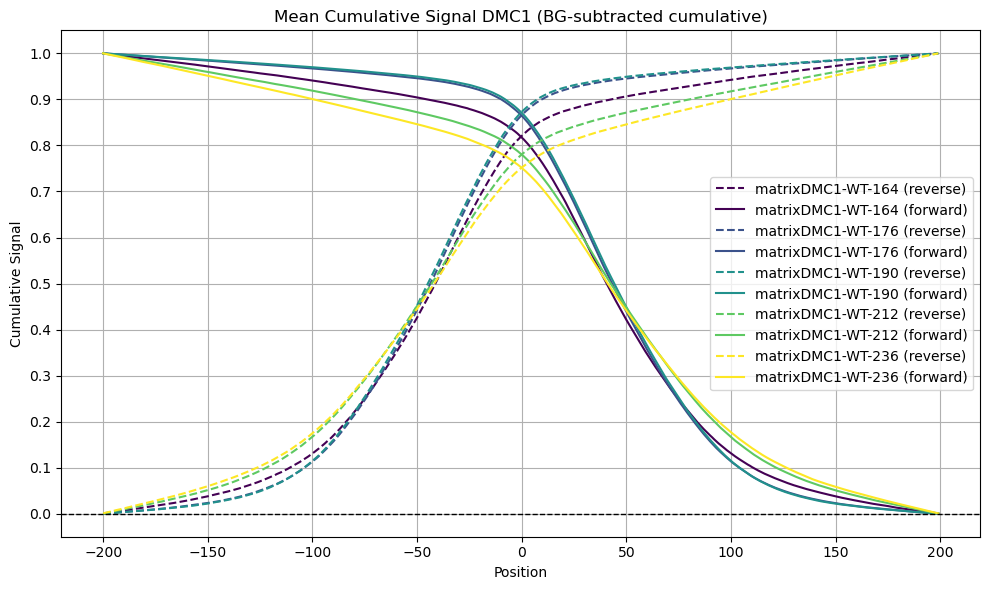

In [37]:
# Step 1: BG subtraction on your raw coverage matrices
bgsub = bg_subtract_coverage(
    dict_mat_dmc1,
    reverse_bg_pos=(100, 200),
    forward_bg_pos=(-200, -100),
    drop_last_col=True
)

# Step 2: Cumulative profiles from bg-subtracted coverage
cumul = compute_cumulative_from_bgsub(
    bgsub,
    output_dir="cumulative_csvs",   # or None to skip saving
    forward_direction="right_to_left",
    reverse_direction="left_to_right",
    save_csv=True
)

# Step 3: Plot overlayed mean cumulative profiles
plot_overlayed_cumulative_from_bgsub(
    cumul,
    experiment_order_dmc1,          # or pass a list for consistent ordering
    title="Mean Cumulative Signal DMC1 (BG-subtracted cumulative)",
    normalize_ticks_to_0_1=True
)

In [ ]:
plot_overlayed_cumulative_bgsub

In [ ]:
plot_overlayed_coverage_with_background_subtraction(dict_mat_rpa, experiment_order)
plot_overlayed_coverage_with_background_subtraction(dict_mat_dmc1, experiment_order_dmc1)

In [51]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import cm

# --- Your compute_cumulative_dict must be defined above exactly as you pasted ---

def bg_subtract_coverage(
    dict_mat,
    forward_bg_pos=(100, 200),   # .iloc positional slice: use columns 100:200 for reverse
    reverse_bg_pos=(-200, -100), # .iloc positional slice: use columns -200:-100 for forward
    drop_last_col=True           # drop a trailing dummy column here
):
    """
    Row-wise background subtraction per experiment, per strand.
    For each row: signal := max(signal - bg, 0), where bg is the row-mean over the background window.
    """
    out = {}
    for exp, mats in dict_mat.items():
        fwd = mats['forward']
        rev = mats['reverse']
        if drop_last_col:
            fwd = fwd.iloc[:, :-1]
            rev = rev.iloc[:, :-1]

        # Reverse background: mean over positional slice
        r_s, r_e = reverse_bg_pos
        rev_bg = rev.iloc[:, r_s:r_e].mean(axis=1, skipna=True)
        rev_bgsub = rev.sub(rev_bg, axis=0).clip(lower=0)

        # Forward background: mean over positional slice
        f_s, f_e = forward_bg_pos
        fwd_bg = fwd.iloc[:, f_s:f_e].mean(axis=1, skipna=True)
        fwd_bgsub = fwd.sub(fwd_bg, axis=0).clip(lower=0)

        out[exp] = {'forward': fwd_bgsub, 'reverse': rev_bgsub}
    return out


def plot_overlayed_cumulative_from_bgsub_pipeline(
    dict_mat,
    experiment_order,
    output_dir,
    forward_bg_pos=(100, 200),
    reverse_bg_pos=(-200, -100),
    title="Mean Cumulative Signal (BG-subtracted → cumulative)",
    normalize_ticks_to_0_1=True
):
    """
    Pipeline:
      1) Background-subtract coverage matrices (drop last col here, clip negatives to 0)
      2) Compute cumulative matrices using your EXACT function (forward L->R, reverse R->L)
      3) Plot overlayed mean cumulative curves (reverse=solid, forward=dashed)
    """
    # 1) BG subtraction (drop_last_col=True here)
    bgsub = bg_subtract_coverage(
        dict_mat,
        reverse_bg_pos=reverse_bg_pos,
        forward_bg_pos=forward_bg_pos,
        drop_last_col=True
    )

    # 2) Your cumulative computation (unchanged)
    cumulative_dict = compute_cumulative_dict(bgsub, output_dir=output_dir)

    # 3) Plot overlayed mean cumulative
    if experiment_order is None:
        experiment_order = list(cumulative_dict.keys())

    plt.figure(figsize=(10, 6))
    cmap = cm.get_cmap('viridis', len(experiment_order))
    color_cycle = [cmap(i) for i in range(len(experiment_order))]

    for i, exp in enumerate(experiment_order):
        fwd_df = cumulative_dict[exp]['forward']
        rev_df = cumulative_dict[exp]['reverse']

        fwd_mean = fwd_df.mean(axis=0, skipna=True)
        rev_mean = rev_df.mean(axis=0, skipna=True)

        # x-axis: cast column labels to numeric if possible
        try:
            x_vals = fwd_mean.index.astype(float)
        except Exception:
            x_vals = pd.to_numeric(fwd_mean.index, errors='coerce')

        color = color_cycle[i]

        # Consistent labeling/style:
        #   Reverse = solid
        #   Forward = dashed
        plt.plot(x_vals, rev_mean.values.astype(float), label=f"{exp} (forward)", linestyle='-',  color=color)
        plt.plot(x_vals, fwd_mean.values.astype(float), label=f"{exp} (reverse)", linestyle='--', color=color)

    plt.title(title)
    plt.xlabel("Position")
    plt.ylabel("Normalized Cumulative Signal")
    plt.axhline(0, color='black', linestyle='--', linewidth=1)
    if normalize_ticks_to_0_1:
        plt.yticks([0,0.1,0.2,0.3,0.4,0.5,0.6,0.7,0.8,0.9,1])
        plt.axhline(1, color='black', linestyle='--', linewidth=1)
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

    return cumulative_dict  # handy if you want to re-use the cumulative matrices

[✓] Saved: cumulative_csvs_bgsub/matrixRPA-WT-164_forward_cumulative.csv
[✓] Saved: cumulative_csvs_bgsub/matrixRPA-WT-164_reverse_cumulative.csv
[✓] Saved: cumulative_csvs_bgsub/matrixRPA-WT-176_forward_cumulative.csv
[✓] Saved: cumulative_csvs_bgsub/matrixRPA-WT-176_reverse_cumulative.csv
[✓] Saved: cumulative_csvs_bgsub/matrixRPA-WT-190_forward_cumulative.csv
[✓] Saved: cumulative_csvs_bgsub/matrixRPA-WT-190_reverse_cumulative.csv
[✓] Saved: cumulative_csvs_bgsub/matrixRPA-WT-212_forward_cumulative.csv
[✓] Saved: cumulative_csvs_bgsub/matrixRPA-WT-212_reverse_cumulative.csv
[✓] Saved: cumulative_csvs_bgsub/matrixRPA-WT-236_forward_cumulative.csv
[✓] Saved: cumulative_csvs_bgsub/matrixRPA-WT-236_reverse_cumulative.csv


/scratch-local/slurm-job-tmp-9148143/ipykernel_169/1026534917.py:72: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  cmap = cm.get_cmap('viridis', len(experiment_order))


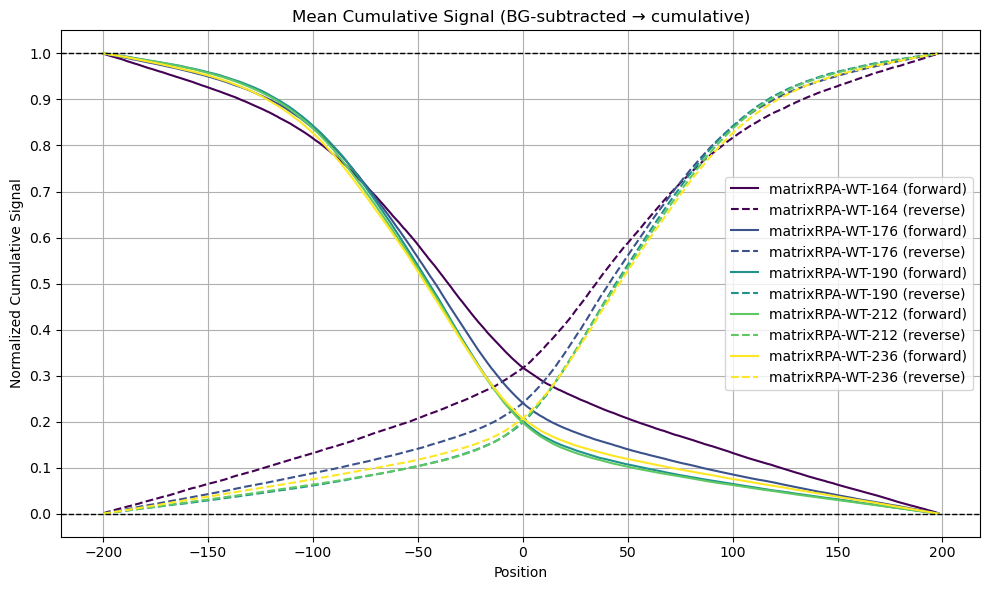

In [52]:
# cumulative_dict_out will also be saved to CSVs in `output_dir` by your function
cumulative_dict_out = plot_overlayed_cumulative_from_bgsub_pipeline(
    dict_mat_rpa,     
    experiment_order,  # your raw coverage matrices
    output_dir="cumulative_csvs_bgsub", # where CSVs go
    reverse_bg_pos=(100, 200),
    forward_bg_pos=(-200, -100)            # or a list like ["t0","t10","t20",...]
)


[✓] Saved: cumulative_csvs_bgsub/matrixDMC1-WT-164_forward_cumulative.csv
[✓] Saved: cumulative_csvs_bgsub/matrixDMC1-WT-164_reverse_cumulative.csv
[✓] Saved: cumulative_csvs_bgsub/matrixDMC1-WT-176_forward_cumulative.csv
[✓] Saved: cumulative_csvs_bgsub/matrixDMC1-WT-176_reverse_cumulative.csv
[✓] Saved: cumulative_csvs_bgsub/matrixDMC1-WT-190_forward_cumulative.csv
[✓] Saved: cumulative_csvs_bgsub/matrixDMC1-WT-190_reverse_cumulative.csv
[✓] Saved: cumulative_csvs_bgsub/matrixDMC1-WT-212_forward_cumulative.csv
[✓] Saved: cumulative_csvs_bgsub/matrixDMC1-WT-212_reverse_cumulative.csv
[✓] Saved: cumulative_csvs_bgsub/matrixDMC1-WT-236_forward_cumulative.csv
[✓] Saved: cumulative_csvs_bgsub/matrixDMC1-WT-236_reverse_cumulative.csv


/scratch-local/slurm-job-tmp-9148143/ipykernel_169/1026534917.py:72: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  cmap = cm.get_cmap('viridis', len(experiment_order))


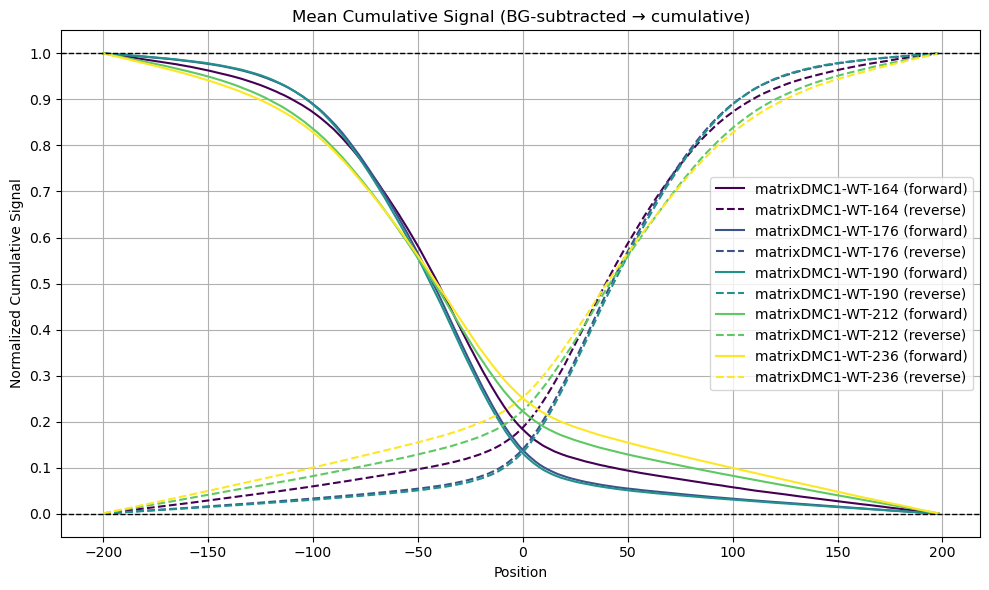

In [53]:
# cumulative_dict_out will also be saved to CSVs in `output_dir` by your function
cumulative_dict_out = plot_overlayed_cumulative_from_bgsub_pipeline(
    dict_mat_dmc1, 
    experiment_order_dmc1,   # your raw coverage matrices
    output_dir="cumulative_csvs_bgsub", # where CSVs go
    reverse_bg_pos=(100, 200),
    forward_bg_pos=(-200, -100)           # or a list like ["t0","t10","t20",...]
)


/scratch-local/slurm-job-tmp-8952058/ipykernel_98/3079032830.py:21: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  cmap = cm.get_cmap('viridis', len(experiment_order))


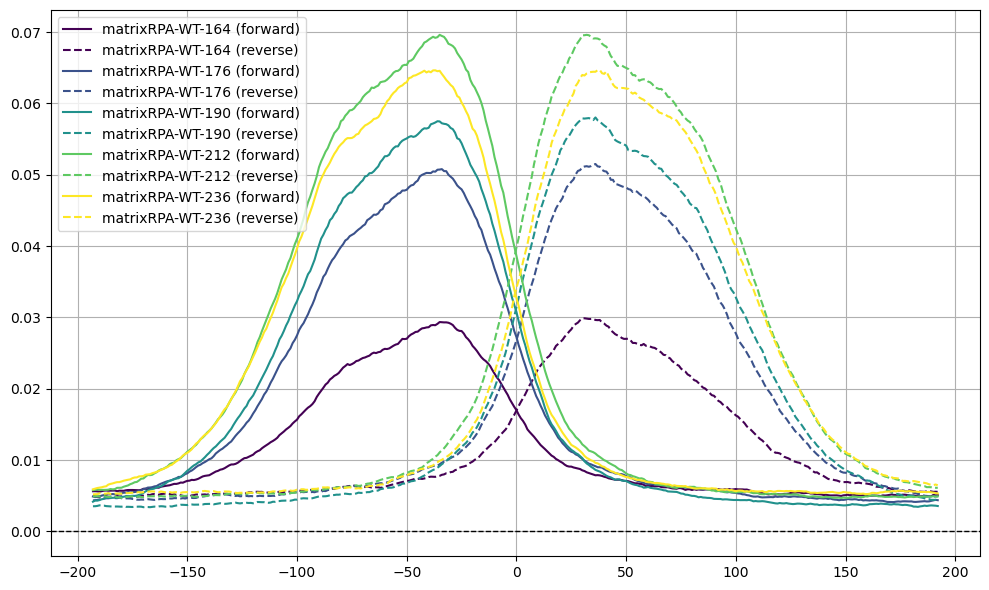

/scratch-local/slurm-job-tmp-8952058/ipykernel_98/3079032830.py:21: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  cmap = cm.get_cmap('viridis', len(experiment_order))


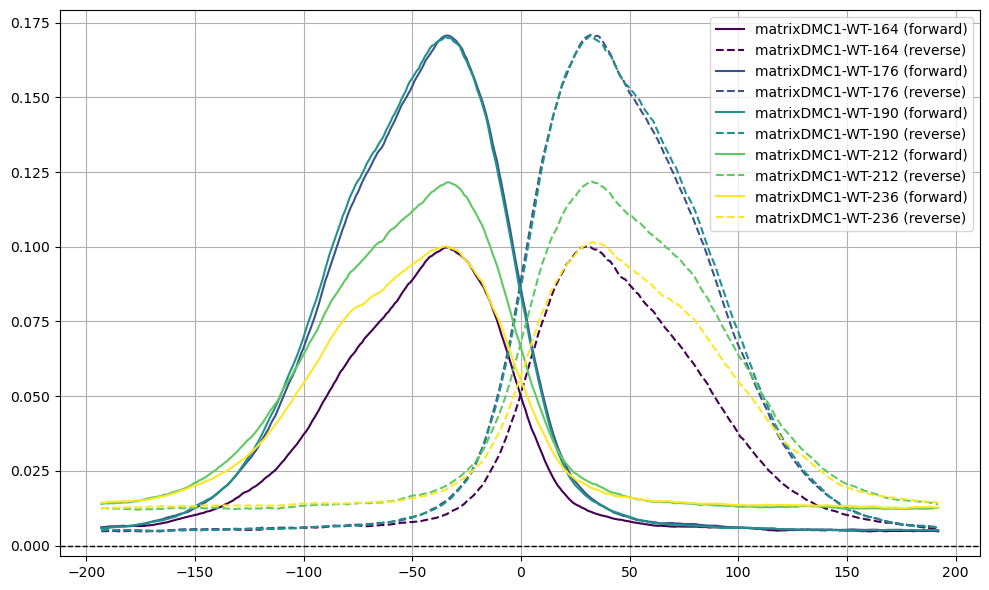

In [55]:
plot_overlayed_coverage_with_background_subtraction(dict_mat_rpa, experiment_order)
plot_overlayed_coverage_with_background_subtraction(dict_mat_dmc1, experiment_order_dmc1)

In [212]:
#cumulative_rpa_dict

In [250]:
def get_percentile_position_dfs(cumulative_dict, percentile_low=0.1, percentile_high=0.9):
    """
    Compute x-positions where cumulative signal crosses low/high percentiles.
    Returns two wide-format DataFrames (forward & reverse) with one row per region,
    and two columns per experiment: <experiment>_10th and <experiment>_90th.

    Args:
        cumulative_dict: dict of {experiment: {'forward': df, 'reverse': df}}
        percentile_low: e.g. 0.1
        percentile_high: e.g. 0.9

    Returns:
        forward_df_wide, reverse_df_wide: wide-format DataFrames
    """
    forward_10th = {}
    forward_90th = {}
    reverse_10th = {}
    reverse_90th = {}

    for experiment, strands in cumulative_dict.items():
        fwd_df = strands['forward']
        rev_df = strands['reverse']
        x_vals = fwd_df.columns.astype(float)

        f10 = []
        f90 = []
        r10 = []
        r90 = []
        idx = []

        for region in fwd_df.index:
            idx.append(region)

            try:
                # Forward (right to left)
                fwd = fwd_df.loc[region].astype(float).values
                fwd_x = x_vals
                #fwd_x = x_vals[::-1]
                fwd_y = fwd
                x10_fwd = np.interp(percentile_low, fwd_y, fwd_x)
                x90_fwd = np.interp(percentile_high, fwd_y, fwd_x)
            except:
                x10_fwd = x90_fwd = np.nan
            f10.append(x10_fwd)
            f90.append(x90_fwd)

            try:
                # Reverse (left to right)
                rev = rev_df.loc[region].astype(float).values[::-1]
                rev_x = x_vals[::-1]
                x10_rev = np.interp(percentile_low, rev, rev_x)
                x90_rev = np.interp(percentile_high, rev, rev_x)
            except:
                x10_rev = x90_rev = np.nan
            r10.append(x10_rev)
            r90.append(x90_rev)

        forward_10th[f"{experiment}_10th"] = pd.Series(f10, index=idx)
        forward_90th[f"{experiment}_90th"] = pd.Series(f90, index=idx)
        reverse_10th[f"{experiment}_10th"] = pd.Series(r10, index=idx)
        reverse_90th[f"{experiment}_90th"] = pd.Series(r90, index=idx)

    # Combine columns
    forward_df = pd.concat([pd.DataFrame(forward_10th), pd.DataFrame(forward_90th)], axis=1)
    reverse_df = pd.concat([pd.DataFrame(reverse_10th), pd.DataFrame(reverse_90th)], axis=1)

    # Optional: sort columns
    forward_df = forward_df.reindex(sorted(forward_df.columns), axis=1)
    reverse_df = reverse_df.reindex(sorted(reverse_df.columns), axis=1)

    return forward_df, reverse_df

In [251]:
fwd_percentile_df_rpa, rev_percentile_df_rpa = get_percentile_position_dfs(cumulative_rpa_dict)

In [252]:
fwd_percentile_df_rpa

,matrixRPA-WT-164_10th,matrixRPA-WT-164_90th,matrixRPA-WT-176_10th,matrixRPA-WT-176_90th,matrixRPA-WT-190_10th,matrixRPA-WT-190_90th,matrixRPA-WT-212_10th,matrixRPA-WT-212_90th,matrixRPA-WT-236_10th,matrixRPA-WT-236_90th
chr1:59358990-59359564,-53.70,67.70,1.725000e+01,106.500000,19.900000,111.100000,-12.866667,127.933333,26.500000,141.500000
chr1:86088048-86088880,-174.30,98.30,-1.105000e+02,91.500000,-116.300000,87.100000,-145.200000,123.400000,-15.000000,192.000000
chr1:58419902-58420598,-36.25,147.25,-1.900833e+01,124.512500,-21.708333,127.059524,-19.000000,131.000000,-18.433333,127.866667
chr1:154652805-154653558,-167.30,105.30,2.070000e+01,123.300000,-10.300000,95.300000,-35.700000,76.900000,-37.450000,115.450000
chr1:67961706-67963003,-40.75,104.75,-5.465417e+01,120.654167,-44.642143,121.642143,-53.788333,124.894167,-9.671667,129.835833
...,...,...,...,...,...,...,...,...,...,...
chrX:169971967-169972919,-144.90,181.90,-1.877000e+02,136.700000,-173.600000,182.300000,-164.333333,155.166667,-173.308333,163.316667
chrX:111598605-111599624,-71.30,191.30,1.387779e-16,191.000000,-115.800000,130.800000,-71.500000,132.500000,-62.400000,136.400000
chrX:112877308-112877827,-200.00,51.50,-1.146000e+02,95.600000,23.000000,184.000000,7.700000,75.300000,6.200000,148.800000
chrX:88485240-88485848,-174.60,175.60,-1.957000e+02,117.700000,-183.500000,121.500000,-85.600000,146.600000,-76.800000,124.800000


In [253]:
rev_percentile_df_rpa

,matrixRPA-WT-164_10th,matrixRPA-WT-164_90th,matrixRPA-WT-176_10th,matrixRPA-WT-176_90th,matrixRPA-WT-190_10th,matrixRPA-WT-190_90th,matrixRPA-WT-212_10th,matrixRPA-WT-212_90th,matrixRPA-WT-236_10th,matrixRPA-WT-236_90th
chr1:59358990-59359564,12.350,-98.350000,4.950000,-111.900000,36.800000,-111.900000,5.525000,-129.525000,5.450,-137.450000
chr1:86088048-86088880,124.300,-161.300000,88.200000,-131.200000,88.100000,-106.766667,-29.800000,-143.200000,72.800,-97.800000
chr1:58419902-58420598,25.100,-130.050000,22.887500,-143.775000,35.933333,-129.216667,35.437500,-130.437500,32.200,-128.200000
chr1:154652805-154653558,83.100,-129.100000,121.566667,-74.700000,77.900000,-60.900000,63.100000,-104.100000,34.100,-154.100000
chr1:67961706-67963003,2.525,-144.525000,17.738333,-144.412778,12.759167,-139.518333,15.848333,-144.949444,-4.710,-144.596667
...,...,...,...,...,...,...,...,...,...,...
chrX:169971967-169972919,183.900,-153.266667,181.950000,-147.950000,183.900000,-112.900000,182.100000,-151.100000,159.375,-142.750000
chrX:111598605-111599624,180.100,-88.100000,182.400000,-80.400000,28.900000,-139.900000,16.300000,-175.300000,91.300,-93.300000
chrX:112877308-112877827,183.200,-156.200000,180.600000,-168.600000,51.200000,-156.200000,131.000000,-138.000000,49.100,-189.100000
chrX:88485240-88485848,153.800,-67.800000,50.700000,-105.850000,103.000000,-55.000000,90.300000,-167.300000,92.100,-88.100000


In [254]:
print("Are the forward and reverse DataFrames equal?")
print(fwd_percentile_df_rpa.equals(rev_percentile_df_rpa))

Are the forward and reverse DataFrames equal?
False


### some test


In [231]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import spearmanr

def plot_percentile_trends(percentile_df, experiment_order):
    """
    Plot mean ± SEM and individual scatter for 10th and 90th percentile positions.
    Also compute Spearman correlation (per row) and show histogram of r-values.

    Args:
        percentile_df: wide-format DataFrame with <exp>_10th and <exp>_90th columns
        experiment_order: list of experiment names in temporal order (no suffixes)
    """
    percentile_types = ['10th', '90th']

    fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharey=True)

    for ax, perc_type in zip(axes, percentile_types):
        cols = [f"{exp}_{perc_type}" for exp in experiment_order]
        sub_df = percentile_df[cols]

        means = sub_df.mean(axis=0, skipna=True)
        sems = sub_df.sem(axis=0, skipna=True)

        x = np.arange(len(cols))

        # Line: Mean ± SEM
        ax.plot(x, means, label='Mean', marker='o', linewidth=2)
        ax.fill_between(x, means - sems, means + sems, alpha=0.3, label='± SEM')

        # Scatter: individual region values
        for xi in x:
            ax.scatter(np.full(sub_df.shape[0], xi), sub_df.iloc[:, xi], alpha=0.2, s=10, color='black')

        ax.set_xticks(x)
        ax.set_xticklabels(experiment_order, rotation=45)
        ax.set_title(f"{perc_type} Percentile Position Over Time")
        ax.set_ylabel("Position")
        ax.set_xlabel("Experiment")
        ax.axhline(0, linestyle='--', color='gray', linewidth=1)
        ax.legend()

    plt.tight_layout()
    plt.show()

    # Also show histogram of Spearman correlation (per region)
    for perc_type in percentile_types:
        cols = [f"{exp}_{perc_type}" for exp in experiment_order]
        sub_df = percentile_df[cols]

        spearman_rs = []
        for _, row in sub_df.iterrows():
            if row.isna().sum() < len(row) - 1:
                r, p = spearmanr(row, np.arange(len(row)))
                spearman_rs.append(r)

        plt.figure(figsize=(6, 4))
        sns.histplot(spearman_rs, kde=True, bins=30)
        plt.title(f"Spearman Correlation (Time) for {perc_type} Percentile")
        plt.xlabel("Spearman r")
        plt.ylabel("Region Count")
        plt.tight_layout()
        plt.show()


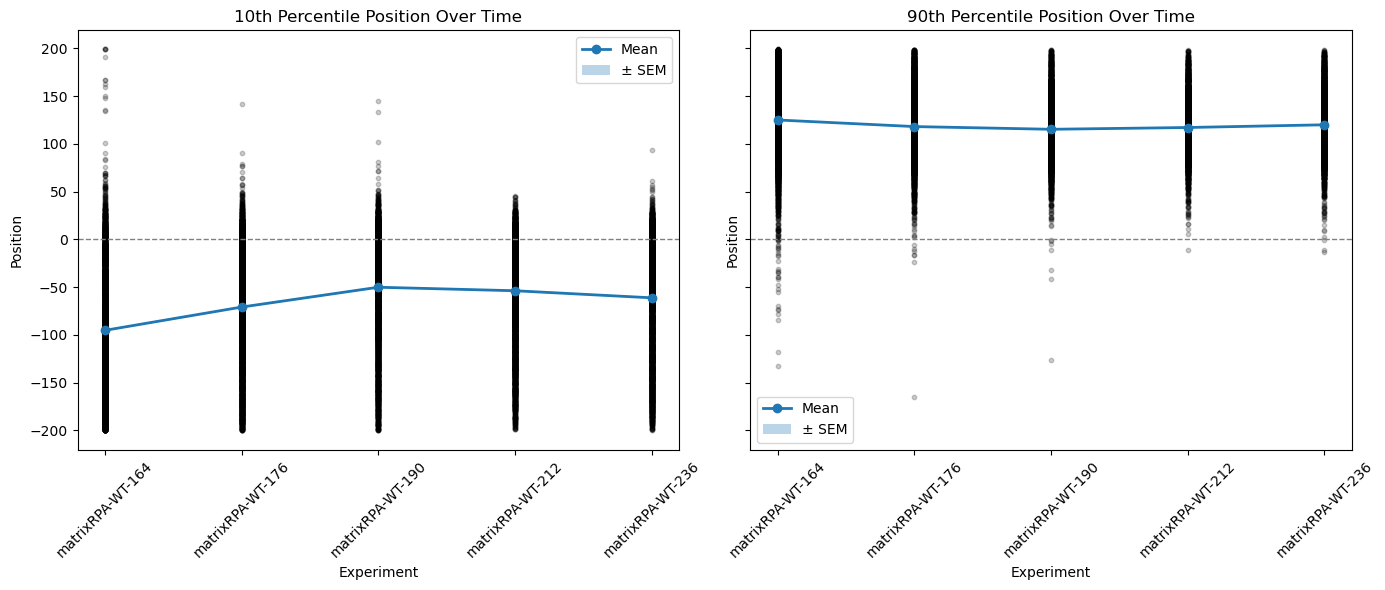

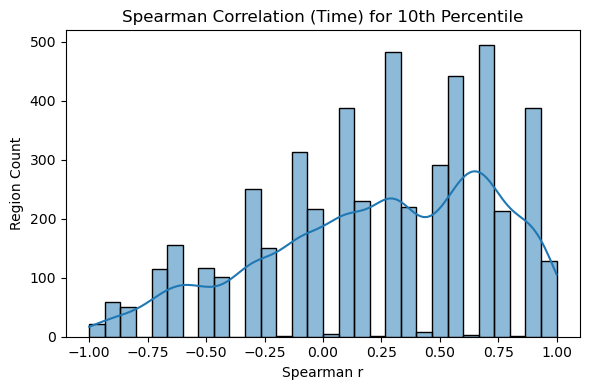

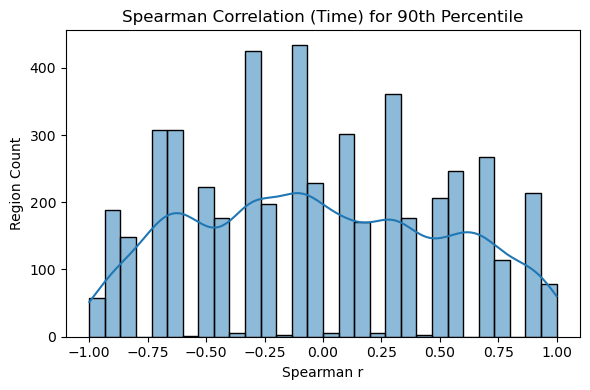

In [232]:
plot_percentile_trends(fwd_percentile_df_rpa, experiment_order)

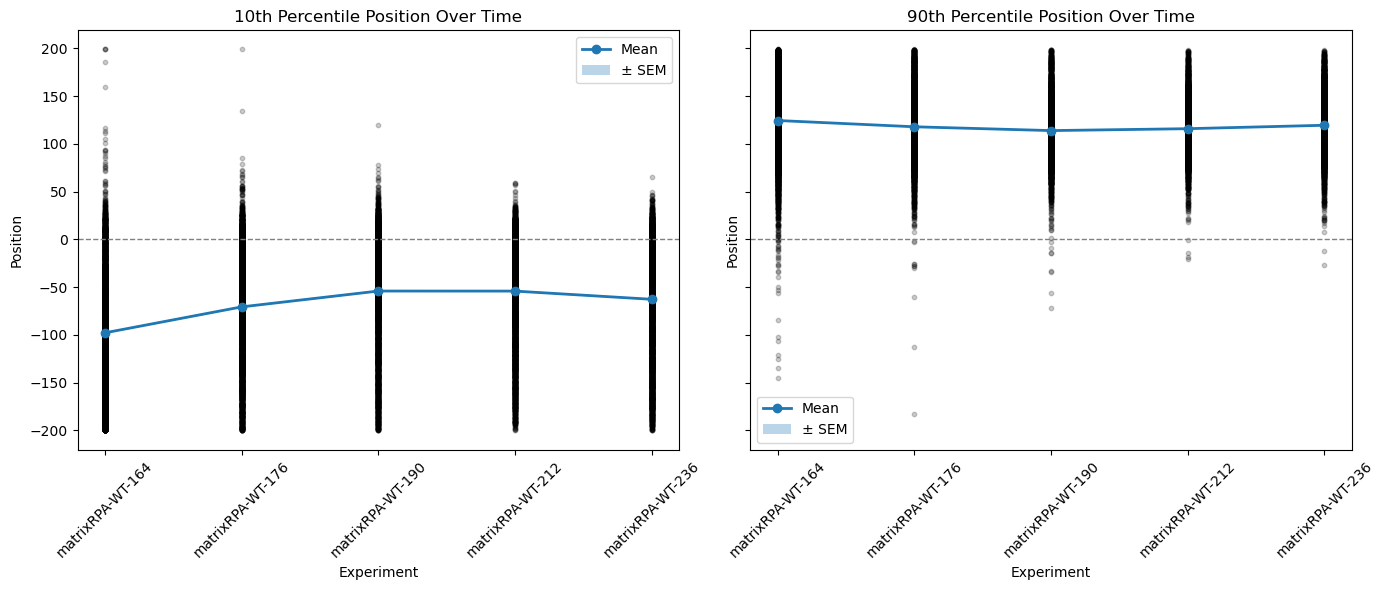

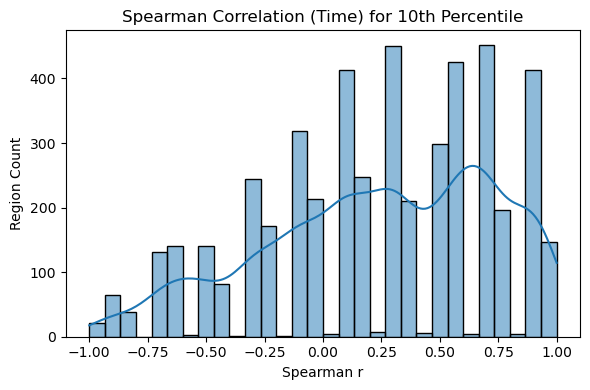

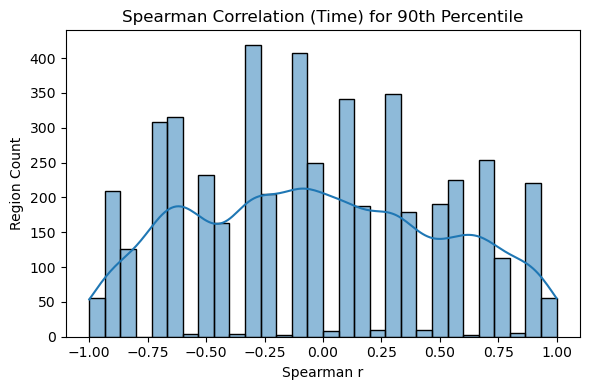

In [233]:
plot_percentile_trends(rev_percentile_df_rpa, experiment_order)

## more test

In [256]:
fwd_percentile_df_dmc1, rev_percentile_df_dmc1 = get_percentile_position_dfs(cumulative_dmc1_dict)

In [257]:
fwd_percentile_df_dmc1

,matrixDMC1-WT-164_10th,matrixDMC1-WT-164_90th,matrixDMC1-WT-176_10th,matrixDMC1-WT-176_90th,matrixDMC1-WT-190_10th,matrixDMC1-WT-190_90th,matrixDMC1-WT-212_10th,matrixDMC1-WT-212_90th,matrixDMC1-WT-236_10th,matrixDMC1-WT-236_90th
chr1:59358990-59359564,12.743333,101.752222,6.160655,109.678690,5.437381,113.250476,-45.025000,146.012500,-45.100000,132.100000
chr1:86088048-86088880,-17.566667,87.950000,-22.819167,105.638333,-37.630000,105.815000,-57.766667,109.766667,-103.050000,171.050000
chr1:58419902-58420598,-18.345833,124.730556,-21.299286,127.590952,-18.515615,133.331230,-20.033333,128.011111,-19.116667,126.116667
chr1:154652805-154653558,16.500000,107.250000,-25.433333,113.433333,-21.706667,108.706667,-51.500000,117.500000,-63.400000,99.400000
chr1:67961706-67963003,-49.085198,124.835198,-56.700258,130.923957,-59.993075,131.993075,-56.551667,149.775833,-41.236667,130.236667
...,...,...,...,...,...,...,...,...,...,...
chrX:169971967-169972919,-165.325000,151.650000,-160.016667,181.008333,-165.598333,170.448333,-165.138559,162.812438,-167.788036,167.117738
chrX:111598605-111599624,-55.200000,115.200000,-47.500000,114.833333,-3.650000,132.650000,-62.200000,136.700000,-9.630000,121.630000
chrX:112877308-112877827,-147.500000,83.500000,-122.266667,75.266667,-78.383333,72.383333,6.030556,89.908333,4.961667,90.038333
chrX:88485240-88485848,-163.600000,147.600000,-76.800000,166.800000,-7.400000,125.400000,-12.800000,123.400000,19.733333,141.133333


In [258]:
rev_percentile_df_dmc1

,matrixDMC1-WT-164_10th,matrixDMC1-WT-164_90th,matrixDMC1-WT-176_10th,matrixDMC1-WT-176_90th,matrixDMC1-WT-190_10th,matrixDMC1-WT-190_90th,matrixDMC1-WT-212_10th,matrixDMC1-WT-212_90th,matrixDMC1-WT-236_10th,matrixDMC1-WT-236_90th
chr1:59358990-59359564,6.662500,-114.825000,8.018095,-117.259048,7.021667,-120.510833,42.100000,-120.100000,151.800000,-138.600000
chr1:86088048-86088880,-16.300000,-143.400000,42.966667,-140.483333,39.160000,-140.580000,75.700000,-177.700000,111.300000,-140.300000
chr1:58419902-58420598,32.838333,-127.838333,41.048730,-128.448730,43.208591,-131.250172,45.850000,-107.850000,44.558333,-129.116667
chr1:154652805-154653558,15.200000,-126.200000,29.166667,-109.166667,15.958333,-129.916667,110.350000,-129.350000,83.900000,-96.900000
chr1:67961706-67963003,24.336865,-131.278955,34.850496,-143.621854,31.650918,-139.564107,32.637063,-143.068532,3.860000,-137.193333
...,...,...,...,...,...,...,...,...,...,...
chrX:169971967-169972919,121.600000,-170.300000,170.916667,-156.458333,160.100000,-145.100000,155.203770,-150.234590,170.126667,-146.460000
chrX:111598605-111599624,92.000000,-80.000000,91.550000,-139.550000,23.900000,-88.900000,18.781667,-85.563333,9.232500,-121.655000
chrX:112877308-112877827,-2.400000,-145.600000,4.066667,-96.533333,-3.650000,-116.350000,-2.998214,-118.401071,-2.037143,-118.962857
chrX:88485240-88485848,141.700000,-109.700000,62.100000,-107.100000,64.100000,-126.100000,24.608333,-105.216667,28.866667,-119.866667


In [239]:
#plot_percentile_trends(fwd_percentile_df_dmc1, experiment_order_dmc1)

In [240]:
#plot_percentile_trends(rev_percentile_df_dmc1, experiment_order_dmc1)

In [243]:
#plot_percentile_trends_split(rev_percentile_df_rpa, fwd_percentile_df_rpa, experiment_order)

In [3]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

def plot_percentile_trends_scatter(percentile_df, experiment_order):
    """
    Plot mean ± SEM, median, and individual data points (scatter) for
    10th and 90th percentile positions over time.

    Args:
        percentile_df: DataFrame with columns like <exp>_10th and <exp>_90th
        experiment_order: list of experiment names in temporal order (no suffix)
    """
    fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharey=False)
    percentile_types = ['10th', '90th']
    colors = {'10th': 'royalblue', '90th': 'crimson'}

    for ax, perc_type in zip(axes, percentile_types):
        means, medians, sems = [], [], []

        for i, exp in enumerate(experiment_order):
            col = f"{exp}_{perc_type}"
            values = percentile_df[col].astype(float)
            means.append(values.mean(skipna=True))
            medians.append(values.median(skipna=True))
            sems.append(values.sem(skipna=True))

            # Scatter: region-wise values with jitter
            y_vals = values.dropna()
            jittered_x = np.random.normal(loc=i, scale=0.1, size=len(y_vals))
            ax.scatter(jittered_x, y_vals, alpha=0.4, color='gray', s=15, label='Region values' if i == 0 else None)

        x = np.arange(len(experiment_order))
        means = np.array(means)
        medians = np.array(medians)
        sems = np.array(sems)

        ax.plot(x, means, color=colors[perc_type], label='Mean', marker='o', linestyle='-', linewidth=2)
        # Optional SEM ribbon
        # ax.fill_between(x, means - sems, means + sems, alpha=0.2, color=colors[perc_type], label='± SEM')
        ax.plot(x, medians, color='black', label='Median', marker='s', linestyle='--', linewidth=2)

        ax.set_xticks(x)
        ax.set_xticklabels(experiment_order, rotation=45)
        ax.set_title(f"{perc_type} Percentile Positions Over Time")
        ax.set_ylabel("Genomic Position")
        ax.set_xlabel("Timecourse")
        ax.axhline(0, color='black', linestyle='--', linewidth=1)
        ax.legend()

    plt.tight_layout()
    plt.show()


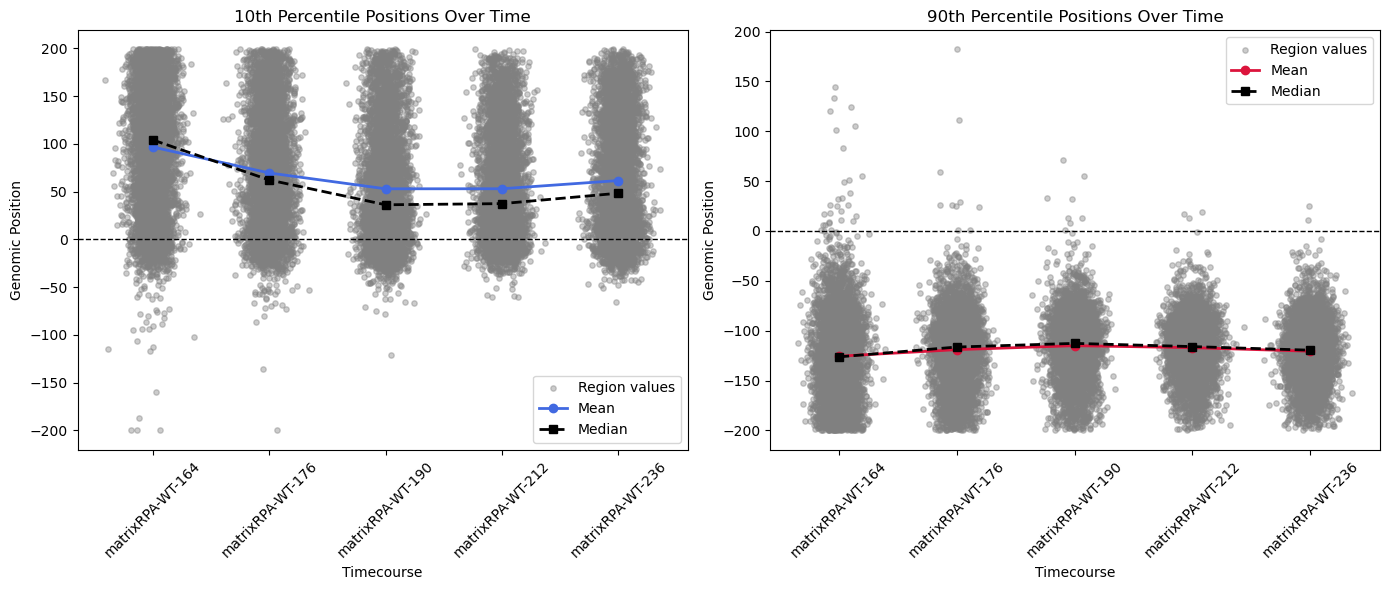

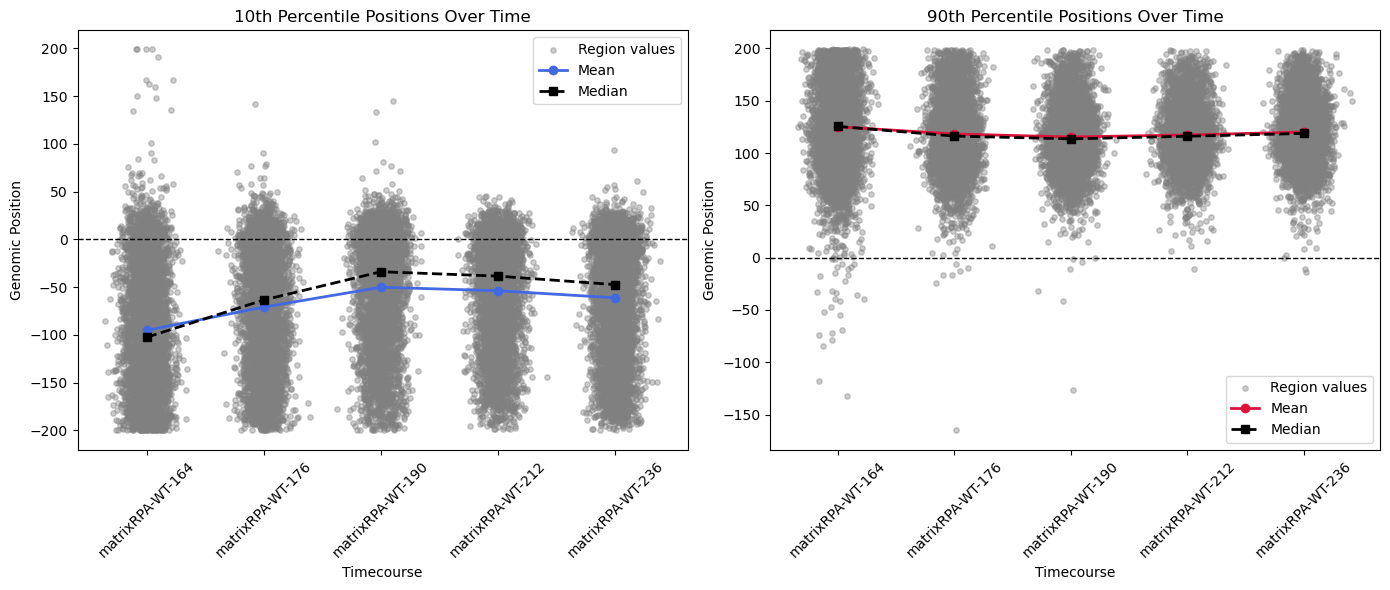

In [255]:
plot_percentile_trends_scatter(rev_percentile_df_rpa, experiment_order)
plot_percentile_trends_scatter(fwd_percentile_df_rpa, experiment_order)

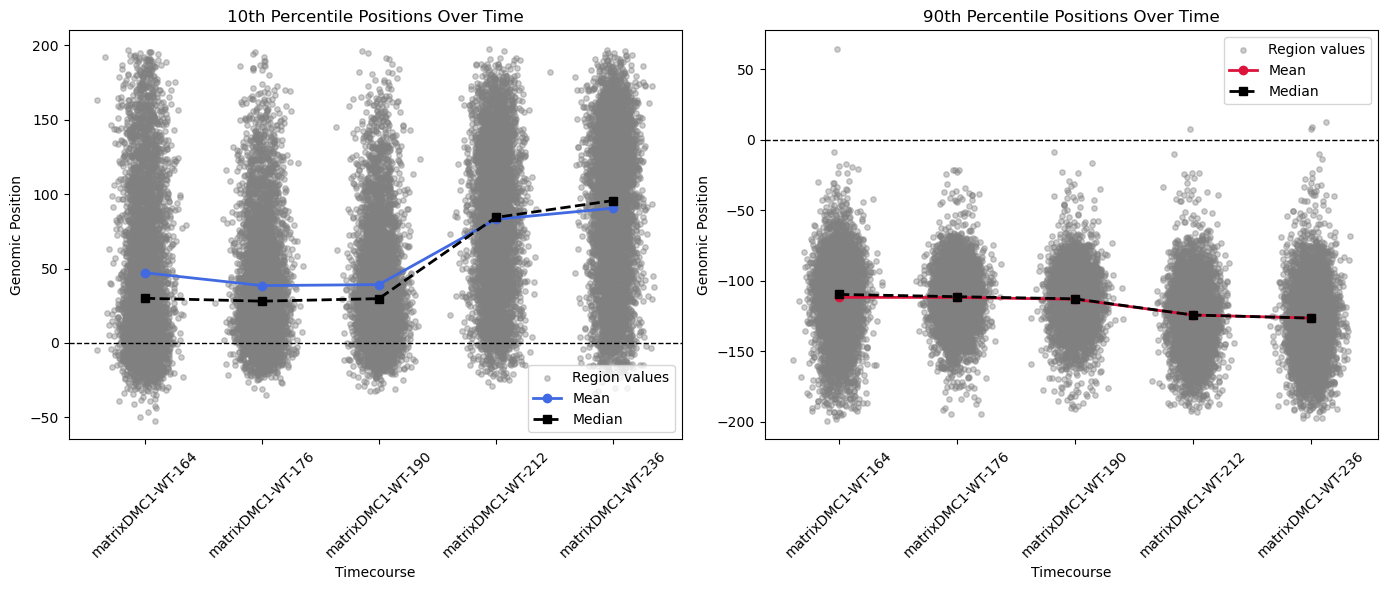

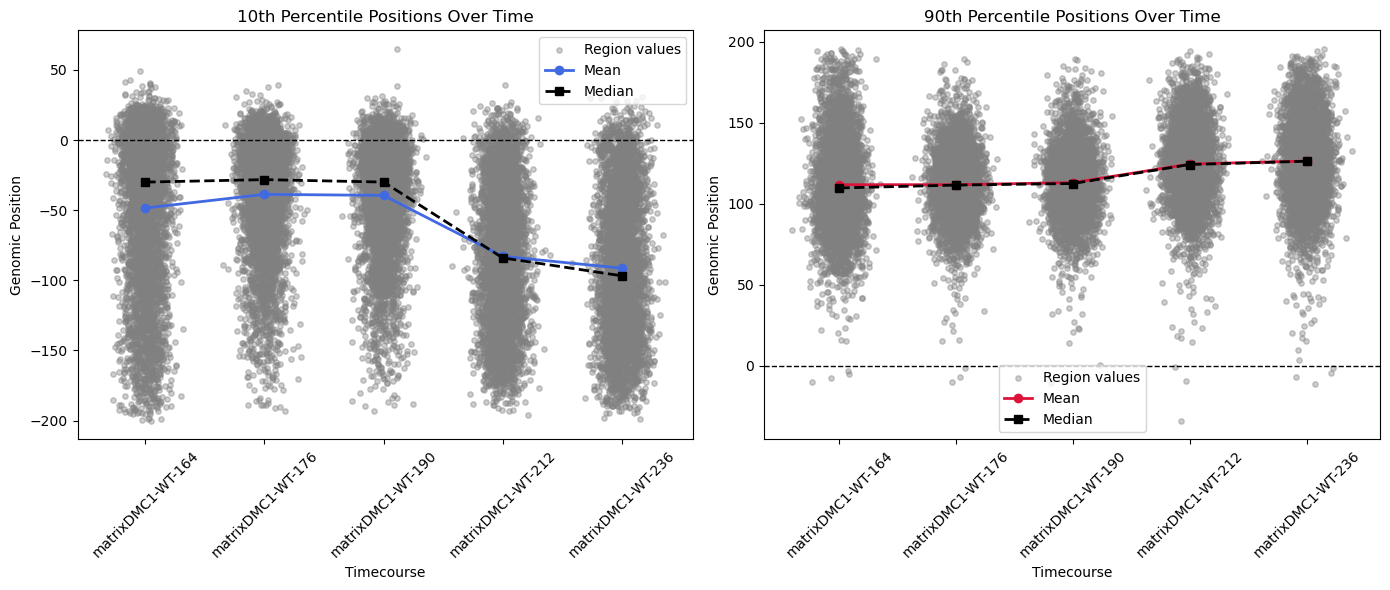

In [259]:
plot_percentile_trends_scatter(rev_percentile_df_dmc1, experiment_order_dmc1)
plot_percentile_trends_scatter(fwd_percentile_df_dmc1, experiment_order_dmc1)